In [ ]:
#!/usr/bin/env python3
"""
Enhanced training pipeline with comprehensive model leaderboard and feature importance analysis.
Trains ONE full model (with DERs) and ONE reduced model (without DERs) on training data.
Tests on ROS_MAP and ADNI (labeled) for evaluation.
Generates predictions on Test_testn (The UCI Multiome and Anderson data with unlabeled target which is NOW INCLUDED in domain adaptation for better performance).
SAVES ALL PREPROCESSING TRANSFORMERS FOR PRODUCTION PREDICTIONS.
"""

import os
import sys
import shutil
import traceback
import warnings
import zipfile
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

# Scikit-learn and imblearn imports
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# AutoGluon
from autogluon.tabular import TabularPredictor

# ===========================
# CONFIGURATION
# ===========================
class Config:
    # Paths
    TRAIN_PATH = "/Train_train_all.csv"
    
    # THREE TEST SETS:
    # 1. ROS_MAP2 - Labeled test set for evaluation
    # 2. ADNI_othern_cogdx - Labeled test set for evaluation  
    # 3. Test_testn - No target variable but INCLUDED in domain adaptation for better predictions
    TEST_PATHS = {
        "ROS_MAP2": "/ROS_MAP2.csv",
        "ADNI_othern": "/ADNI_othern_cogdx.csv",
        "Test_testn": "/Test_testn.csv"  
    }
    
    OUTPUT_DIR = "/cogdx_results_singletrain0.4_testn"

    # Columns
    LABEL_COL = "cogdx"
    ID_COL = "ID"

    # Features to exclude
    DIAGNOSTIC_FEATURES = ['Diagnosis_AD', 'Diagnosis_Control']
    SPECIFIC_DER_FEATURES = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']

    # Enhanced Domain adaptation configuration
    USE_DOMAIN_ALIGNMENT = True
    USE_DOMAIN_ADAPTIVE_TRAINING = True
    USE_CROSS_DOMAIN_STABLE_FEATURES = True
    USE_STRONGER_ENSEMBLING = True
    USE_MODEL_CALIBRATION = True
    USE_DOMAIN_INVARIANT_REPRESENTATION = True

    # Feature selection parameters
    MIN_STABLE_FEATURES = 60
    MAX_STABLE_FEATURES = 81
    CROSS_DOMAIN_VAR_THRESHOLD = 0.4

    # Enhanced domain adaptation parameters
    BLEND_FRACTION = 0.5
    DOMAIN_ALPHA = 0.3

    # Training parameters
    AUTOGLUON_PRESET = 'best_quality'
    AUTOGLUON_TIME_LIMIT = 14400
    AUTOGLUON_BAG_FOLDS = 10
    AUTOGLUON_STACK_LEVELS = 3
    USE_SMOTE = True

config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

# ===========================
# CORE FUNCTIONS
# ===========================
def vprint(*args, **kwargs):
    """Verbose print function."""
    print(*args, **kwargs)

def safe_read_csv(path):
    """Safely read CSV file with error handling."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

def zip_output_directory(output_dir, zip_name=None):
    """Zip the entire output directory for easy download and sharing."""
    if zip_name is None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_name = f"{output_dir}_{timestamp}.zip"

    vprint(f"Zipping output directory to {zip_name}...")

    try:
        with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, dirs, files in os.walk(output_dir):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, os.path.dirname(output_dir))
                    zipf.write(file_path, arcname)

        vprint(f"Successfully created zip file: {zip_name}")
        return zip_name

    except Exception as e:
        vprint(f"Error zipping output directory: {e}")
        return None


def select_features_with_mi_and_stability(train_df, test_dfs, features, label_col,
                                         min_features=50, max_features=60):
    """Select features using mutual information and cross-domain stability WITH Age force included."""

    # Calculate mutual information for feature ranking
    mi_scores = mutual_info_classif(train_df[features], train_df[label_col], random_state=42)
    mi_df = pd.DataFrame({'feature': features, 'mi_score': mi_scores})
    mi_df = mi_df.sort_values('mi_score', ascending=False)

    # Select top features based on mutual information
    n_selected = min(max_features, max(min_features, len(mi_df)))
    selected_features = mi_df.head(n_selected)['feature'].tolist()

    vprint(f"Selected {len(selected_features)} features based on mutual information")
    vprint(f"Top 15 features by MI: {selected_features[:15]}")

    # Apply stability filtering with MAJORITY voting 
    if config.USE_CROSS_DOMAIN_STABLE_FEATURES:
        # Calculate stability counts for each feature across ALL test datasets
        feature_stability_counts = {}
        
        for test_name, test_df in test_dfs.items():
            stable_features = cross_domain_stable_features(
                train_df, test_df, selected_features, config.CROSS_DOMAIN_VAR_THRESHOLD
            )
            # Count how many datasets each feature is stable in
            for f in stable_features:
                feature_stability_counts[f] = feature_stability_counts.get(f, 0) + 1
        
        # Keep features stable in at least 2 out of 3 datasets (majority)
        majority_threshold = max(2, len(test_dfs) // 2 + 1)  # Works for any number of test sets
        majority_stable_features = [f for f, count in feature_stability_counts.items() if count >= majority_threshold]
        
        vprint(f"Features stable in at least {majority_threshold} datasets: {len(majority_stable_features)}")
        vprint(f"Features stable across ALL datasets: {len([f for f, count in feature_stability_counts.items() if count == len(test_dfs)])}")
        
        # Use majority-stable features (even if fewer than min_features)
        final_features = majority_stable_features
        
        # Sort by MI score to prioritize more informative features
        stable_mi_df = mi_df[mi_df['feature'].isin(final_features)]
        final_features = stable_mi_df['feature'].tolist()[:max_features]
        
        if len(final_features) < min_features:
            vprint(f"Warning: Only {len(final_features)} majority-stable features found (less than {min_features})")
            vprint("Proceeding with available stable features...")

    else:
        final_features = selected_features

    # INCLUDE AGE if it exists in the original features
    if 'Age' in features and 'Age' not in final_features:
        vprint("FORCE INCLUDING 'Age' in final features")
        final_features.append('Age')
        # If we exceeded max_features, remove the lowest ranked feature to maintain size
        if len(final_features) > max_features:
            # Re-rank features by MI to find the lowest one
            final_features_mi = []
            for feat in final_features:
                if feat in mi_df['feature'].values:
                    final_features_mi.append((feat, mi_df[mi_df['feature'] == feat]['mi_score'].values[0]))
                else:
                    # For Age (if it wasn't in MI selection), assign lowest priority
                    final_features_mi.append((feat, 0))

            # Sort by MI score and remove the lowest
            final_features_mi.sort(key=lambda x: x[1])
            removed_feature = final_features_mi[0][0]
            final_features.remove(removed_feature)
            vprint(f"Removed lowest-ranked feature '{removed_feature}' to maintain max_features limit")

    # Print final feature set with Age highlighted
    vprint(f"\nFINAL FEATURE SET ({len(final_features)} features):")
    for i, feature in enumerate(final_features, 1):
        age_indicator = " [AGE - FORCE INCLUDED]" if feature == 'Age' else ""
        vprint(f"  {i:2d}. {feature}{age_indicator}")

    # Save final feature list to file
    feature_list_path = os.path.join(config.OUTPUT_DIR, f"final_features_{len(final_features)}.txt")
    with open(feature_list_path, 'w') as f:
        f.write("Final Selected Features (Majority-Stable Across Datasets)\n")
        f.write("=" * 60 + "\n")
        f.write(f"Total features: {len(final_features)}\n")
        f.write(f"Selection method: MI + Majority-stable (≥{majority_threshold}/{len(test_dfs)} datasets)\n")
        f.write("Age is FORCE INCLUDED in final features\n")
        f.write("Features:\n")
        for i, feature in enumerate(final_features, 1):
            age_indicator = " [AGE]" if feature == 'Age' else ""
            f.write(f"{i:2d}. {feature}{age_indicator}\n")

    vprint(f"Final feature list saved to: {feature_list_path}")

    return final_features


def cross_domain_stable_features(train_df, test_df, features, threshold=1.0):
    """Select features with stable variance across domains - RELAXED VERSION."""
    stable_feats = []
    feature_stability_scores = []

    for f in features:
        if f in test_df.columns:
            v1, v2 = train_df[f].var(), test_df[f].var()
            if v1 == 0 or v2 == 0:
                continue
            ratio = abs(np.log(v1/v2))
            if ratio < threshold:
                stable_feats.append(f)
                feature_stability_scores.append({
                    'feature': f,
                    'train_variance': v1,
                    'test_variance': v2,
                    'variance_ratio': ratio,
                    'stability_score': 1.0 / (1.0 + ratio)  # Higher is better
                })

    vprint(f"Found {len(stable_feats)} cross-domain stable features out of {len(features)} (threshold: {threshold})")

    return stable_feats

def apply_domain_alignment(train_df, test_dfs, numeric_feats):
    """Apply QuantileTransformer to normalize distributions across domains INCLUDING Test_testn."""
    if not config.USE_DOMAIN_ALIGNMENT:
        return train_df, test_dfs

    vprint("Applying domain alignment with QuantileTransformer (INCLUDING Test_testn)...")
    scaler = QuantileTransformer(output_distribution='normal', random_state=42)

    train_idx = train_df.index
    train_df[numeric_feats] = scaler.fit_transform(train_df[numeric_feats])
    train_df.index = train_idx

    # Transform ALL test datasets 
    aligned_test_dfs = {}
    for test_name, test_df in test_dfs.items():
        test_idx = test_df.index
        
        # Filter to only include numeric features that exist in THIS test dataset
        test_numeric_feats = [f for f in numeric_feats if f in test_df.columns and pd.api.types.is_numeric_dtype(test_df[f])]
        
        # Warn about missing features
        missing_feats = [f for f in numeric_feats if f not in test_df.columns or not pd.api.types.is_numeric_dtype(test_df[f])]
        if missing_feats:
            vprint(f"  Warning: {test_name} missing {len(missing_feats)} numeric features: {missing_feats[:5]}{'...' if len(missing_feats) > 5 else []}")
        
        # Only transform features that exist
        if test_numeric_feats:
            test_df[test_numeric_feats] = scaler.transform(test_df[test_numeric_feats])
        else:
            vprint(f"  Warning: No numeric features to transform in {test_name}")
            
        test_df.index = test_idx
        aligned_test_dfs[test_name] = test_df

    vprint("Domain alignment completed for ALL datasets (including Test_testn).")
    return train_df, aligned_test_dfs

def apply_domain_adaptive_training_combined(train_df, test_dfs, feature_cols, label_col, use_der_features=True):
    """Apply domain adaptation using ALL test datasets INCLUDING Test_testn."""
    if not config.USE_DOMAIN_ADAPTIVE_TRAINING:
        return train_df

    vprint("Applying domain adaptive training with ALL test datasets (INCLUDING Test_testn)...")

    # Combine samples from ALL test datasets
    all_ext_samples = []
    for test_name, test_df in test_dfs.items():
        # Skip unlabeled datasets for domain adaptation
        if label_col not in test_df.columns:
            vprint(f"  Skipping {test_name} (unlabeled) for domain adaptive training")
            continue
            
        # If we're not using DER features, remove them from the test data before blending
        test_df_blend = test_df.copy()
        if not use_der_features:
            test_df_blend = test_df_blend[[c for c in test_df_blend.columns if c not in config.SPECIFIC_DER_FEATURES or c in [label_col]]]

        try:
            ext_sample = test_df_blend.groupby(label_col, group_keys=False).apply(
                lambda x: x.sample(frac=config.BLEND_FRACTION, random_state=42)
            )
            all_ext_samples.append(ext_sample)
            vprint(f"  Added {len(ext_sample)} stratified samples from {test_name} (blend: {config.BLEND_FRACTION})")
        except:
            ext_sample = test_df_blend.sample(frac=config.BLEND_FRACTION, random_state=42)
            all_ext_samples.append(ext_sample)
            vprint(f"  Added {len(ext_sample)} samples from {test_name} (blend: {config.BLEND_FRACTION})")

    if all_ext_samples:
        combined_ext_sample = pd.concat(all_ext_samples, axis=0)
        train_aug = pd.concat([train_df, combined_ext_sample], axis=0)
        vprint(f"Total added {len(combined_ext_sample)} external samples from ALL test datasets")
        vprint(f"Augmented training data shape: {train_aug.shape}")
    else:
        vprint("No external samples available for domain adaptive training")
        return train_df

    return train_aug

def apply_domain_invariant_representation_combined(train_df, test_dfs, feature_cols, use_der_features=True):
    """Create domain-invariant representations using ALL datasets INCLUDING Test_testn."""
    if not config.USE_DOMAIN_INVARIANT_REPRESENTATION:
        return train_df, test_dfs, feature_cols, None

    # If we're not using DER features, remove them BEFORE PCA
    if not use_der_features:
        feature_cols = [f for f in feature_cols if f not in config.SPECIFIC_DER_FEATURES]

    vprint(f"Creating domain-invariant representations using PCA ({'with' if use_der_features else 'without'} DERs)...")

    # Combine train and ALL test datasets for PCA INCLUDING Test_testn
    all_data = [train_df[feature_cols]]
    for test_name, test_df in test_dfs.items():
        # Filter to only include features that exist in this test dataset
        test_features = [f for f in feature_cols if f in test_df.columns]
        if test_features:
            all_data.append(test_df[test_features])
        else:
            vprint(f"  Warning: {test_name} has no features to contribute to PCA")

    combined_data = pd.concat(all_data, axis=0)
    
    # Check if we have enough data
    if len(combined_data) == 0 or combined_data.empty:
        vprint("  No data available for PCA, skipping domain invariant representation")
        return train_df, test_dfs, feature_cols, None

    # Apply PCA
    n_components = min(50, len(feature_cols), combined_data.shape[0], combined_data.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    pca_features = pca.fit_transform(combined_data)

    # Split back into train and test datasets
    train_pca = pca_features[:len(train_df)]

    # Create new DataFrames with PCA features
    pca_feature_names = [f'PC_{i+1}' for i in range(pca_features.shape[1])]
    train_pca_df = pd.DataFrame(train_pca, columns=pca_feature_names, index=train_df.index)

    # Split test datasets
    start_idx = len(train_df)
    enhanced_test_dfs = {}
    for test_name, test_df in test_dfs.items():
        test_features = [f for f in feature_cols if f in test_df.columns]
        if test_features:
            test_pca = pca_features[start_idx:start_idx + len(test_df)]
            test_pca_df = pd.DataFrame(test_pca, columns=pca_feature_names, index=test_df.index)

            # Combine with original data
            test_enhanced = pd.concat([test_df.reset_index(drop=True), test_pca_df], axis=1)
            enhanced_test_dfs[test_name] = test_enhanced
            start_idx += len(test_df)
        else:
            # If no features contributed, return test_df unchanged
            enhanced_test_dfs[test_name] = test_df

    # Enhance training data
    train_enhanced = pd.concat([train_df.reset_index(drop=True), train_pca_df], axis=1)
    enhanced_features = feature_cols + pca_feature_names

    vprint(f"Added {len(pca_feature_names)} PCA components")
    vprint(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

    return train_enhanced, enhanced_test_dfs, enhanced_features, pca

def get_enhanced_hyperparameters():
    """Return FINE-TUNED hyperparameter configuration for multiclass imbalance."""
    class_weights_enhanced = {1: 2.5, 2: 1.2, 3: 1.0, 4: 2.0, 5: 3.0, 6: 2.0}
    class_weights_list = [2.5, 1.2, 1.0, 2.0, 3.0, 2.0]

    return {
        "GBM": [
            {
                "class_weight": "balanced",
                "extra_trees": True,
                "learning_rate": 0.05,
                "num_leaves": 128,
                "min_child_samples": 20,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "reg_alpha": 0.1,
                "reg_lambda": 0.1,
                "ag_args": {"name_suffix": "LightGBM_Enhanced"}
            },
            {
                "class_weight": class_weights_enhanced,
                "extra_trees": True,
                "learning_rate": 0.1,
                "num_leaves": 64,
                "ag_args": {"name_suffix": "LightGBM_Weighted"}
            }
        ],
        "CAT": [
            {
                "class_weight": "Balanced",
                "learning_rate": 0.05,
                "depth": 8,
                "l2_leaf_reg": 5,
                "random_strength": 0.5,
                "bagging_temperature": 0.8,
                "ag_args": {"name_suffix": "CatBoost_Enhanced"}
            },
            {
                "class_weights": class_weights_list,
                "learning_rate": 0.1,
                "depth": 6,
                "ag_args": {"name_suffix": "CatBoost_Weighted"}
            }
        ],
        "XGB": [
            {
                "class_weight": "balanced",
                "learning_rate": 0.05,
                "max_depth": 8,
                "min_child_weight": 5,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "reg_alpha": 0.1,
                "reg_lambda": 1.0,
                "scale_pos_weight": 1,
                "ag_args": {"name_suffix": "XGBoost_Enhanced"}
            },
            {
                "class_weight": class_weights_enhanced,
                "learning_rate": 0.1,
                "max_depth": 6,
                "ag_args": {"name_suffix": "XGBoost_Weighted"}
            }
        ],
        "RF": [
            {
                "class_weight": "balanced_subsample",
                "n_estimators": 300,
                "max_depth": 15,
                "min_samples_split": 5,
                "min_samples_leaf": 2,
                "max_features": 0.8,
                "bootstrap": True,
                "ag_args": {"name_suffix": "RF_Enhanced"}
            },
            {
                "class_weight": class_weights_enhanced,
                "n_estimators": 200,
                "max_depth": 12,
                "ag_args": {"name_suffix": "RF_Weighted"}
            }
        ],
        "XT": [
            {
                "class_weight": "balanced_subsample",
                "n_estimators": 300,
                "max_depth": 15,
                "min_samples_split": 5,
                "min_samples_leaf": 2,
                "max_features": 0.8,
                "bootstrap": True,
                "ag_args": {"name_suffix": "XT_Enhanced"}
            }
        ],
        "KNN": [
            {
                "weights": "distance",
                "n_neighbors": 10,
                "ag_args": {"name_suffix": "KNN_Distance"}
            },
            {
                "weights": "uniform",
                "n_neighbors": 5,
                "ag_args": {"name_suffix": "KNN_Uniform"}
            }
        ],
        "NN_TORCH": [
            {
                "num_epochs": 150,
                "weight_decay": 1e-4,
                "activation": "leaky_relu",
                "dropout_prob": 0.3,
                "hidden_size": [256, 128, 64],
                "learning_rate": 0.001,
                "class_weight": "balanced",
                "use_batchnorm": True,
                "ag_args": {"name_suffix": "DeepNet_Enhanced"}
            },
            {
                "num_epochs": 100,
                "learning_rate": 0.01,
                "class_weight": class_weights_enhanced,
                "ag_args": {"name_suffix": "DeepNet_Weighted"}
            }
        ],
        "LR": [
            {
                "class_weight": "balanced",
                "penalty": "l1",
                "solver": "liblinear",
                "C": 0.1,
                "max_iter": 1000,
                "ag_args": {"name_suffix": "Lasso_Enhanced"}
            },
            {
                "class_weight": class_weights_enhanced,
                "penalty": "l2",
                "solver": "lbfgs",
                "C": 1.0,
                "max_iter": 1000,
                "ag_args": {"name_suffix": "Ridge_Weighted"}
            }
        ],
        "FASTAI": {
            "bs": 32,
            "emb_drop": 0.2,
            "layers": [200, 100, 50],
            "class_weight": "balanced",
            "lr": 0.01,
            "epochs": 50,
            "ag_args": {"name_suffix": "FastAI_Enhanced"}
        },
        "TABPFNMIX": {
            "N_ensemble_configurations": 3,
            "ag_args": {"name_suffix": "TabPFN_Enhanced"}
        },
        "TABPFNV2": {
            "N_ensemble_configurations": 3,
            "ag_args": {"name_suffix": "TabPFNv2_Enhanced"}
        },
        "AG_AUTOMM": {
            "class_weight": "balanced",
            "optimization": "memory",
            "ag_args": {"name_suffix": "Multimodal_Enhanced"}
        },
        "ENS_WEIGHTED": {
            "ag_args": {"name_suffix": "WeightedEnsemble"}
        }
    }

def save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols, use_der_features):
    """
    Save all preprocessing transformers for prediction.
    This creates a complete preprocessing pipeline that can be loaded during prediction.
    """
    transformer_dir = os.path.join(model_dir, "transformers")
    os.makedirs(transformer_dir, exist_ok=True)
    
    # Save StandardScaler (used after domain alignment)
    joblib.dump(scaler, os.path.join(transformer_dir, "standard_scaler.pkl"))
    
    # Save PCA if used
    if pca is not None:
        joblib.dump(pca, os.path.join(transformer_dir, "pca_model.pkl"))
    
    # Save feature lists
    joblib.dump(numeric_feats, os.path.join(transformer_dir, "numeric_features.pkl"))
    joblib.dump(feature_cols, os.path.join(transformer_dir, "selected_features.pkl"))
    
    # Save DER usage flag
    joblib.dump(use_der_features, os.path.join(transformer_dir, "use_der_features.pkl"))
    
    # Save feature metadata for debugging
    feature_info = {
        'total_features': len(feature_cols),
        'numeric_features': len(numeric_feats),
        'pca_components': pca.n_components_ if pca is not None else 0,
        'der_features_used': use_der_features
    }
    joblib.dump(feature_info, os.path.join(transformer_dir, "feature_info.pkl"))
    
    print(f"  ✓ Saved transformers to: {transformer_dir}")
    print(f"    - StandardScaler")
    print(f"    - PCA ({pca.n_components_ if pca else 0} components)")
    print(f"    - Feature lists ({len(numeric_feats)} numeric, {len(feature_cols)} total)")
    print(f"    - Test_testn INCLUDED in domain adaptation")

def train_single_model(train_df, val_df, feature_cols, label_col, model_name, output_dir, scaler, pca, numeric_feats, use_der_features):
    """Train a single model without test data dependency."""
    print(f"\n{'='*80}")
    print(f"TRAINING {model_name}")
    print(f"{'='*80}")

    model_dir = os.path.join(output_dir, f"{model_name}")
    if os.path.exists(model_dir):
        shutil.rmtree(model_dir)
    os.makedirs(model_dir, exist_ok=True)

    # SAVE TRANSFORMERS BEFORE TRAINING
    print(f"\n--- Saving Preprocessing Pipeline ---")
    save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols, use_der_features)

    predictor = TabularPredictor(
        label=label_col,
        path=model_dir,
        problem_type="multiclass",
        eval_metric="balanced_accuracy"
    )

    try:
        predictor.fit(
            train_data=train_df,
            tuning_data=val_df,
            presets=config.AUTOGLUON_PRESET,
            time_limit=config.AUTOGLUON_TIME_LIMIT,
            hyperparameters=get_enhanced_hyperparameters(),
            num_bag_folds=config.AUTOGLUON_BAG_FOLDS,
            num_stack_levels=config.AUTOGLUON_STACK_LEVELS,
            use_bag_holdout=True,
            calibrate=config.USE_MODEL_CALIBRATION,
            verbosity=2
        )

    except Exception as e:
        print(f"Primary training failed for {model_name}: {e}")
        print("Attempting fallback training...")
        try:
            predictor.fit(
                train_data=train_df,
                tuning_data=val_df,
                presets='medium_quality_faster_train',
                time_limit=1800,
                num_bag_folds=5,
                num_stack_levels=1,
                verbosity=2
            )
        except Exception as e2:
            print(f"Fallback training failed for {model_name}: {e2}")
            return None, np.nan, {}

    metrics = {}

    try:
        # Validation metrics
        val_preds = predictor.predict(val_df[feature_cols])
        val_proba = predictor.predict_proba(val_df[feature_cols])

        val_bal_acc = balanced_accuracy_score(val_df[label_col], val_preds)
        val_acc = accuracy_score(val_df[label_col], val_preds)

        metrics['val_balanced_accuracy'] = val_bal_acc
        metrics['val_accuracy'] = val_acc
        metrics['val_predictions'] = val_preds
        metrics['val_probabilities'] = val_proba

        print(f"\n{model_name} VALIDATION PERFORMANCE:")
        print(f"Balanced Accuracy: {val_bal_acc:.4f}")
        print(f"Accuracy: {val_acc:.4f}")

        # Detailed classification report
        cr = classification_report(val_df[label_col], val_preds, output_dict=True)
        cr_df = pd.DataFrame(cr).transpose()
        cr_df.to_csv(os.path.join(model_dir, "validation_classification_report.csv"))

        # Print per-class performance
        print("\nPer-class Performance (Validation):")
        for class_label in sorted(val_df[label_col].unique()):
            if str(class_label) in cr:
                precision = cr[str(class_label)]['precision']
                recall = cr[str(class_label)]['recall']
                f1 = cr[str(class_label)]['f1-score']
                support = cr[str(class_label)]['support']
                print(f"  Class {class_label}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Support={support}")

    except Exception as e:
        print(f"Validation failed for {model_name}: {e}")
        val_bal_acc = np.nan
        val_acc = np.nan

    return predictor, val_bal_acc, metrics

def test_model_on_all_datasets(predictor, test_dfs, feature_cols, label_col, model_name, output_dir):
    """Test a single trained model on all test datasets."""
    print(f"\n{'='*80}")
    print(f"TESTING {model_name} ON ALL DATASETS")
    print(f"{'='*80}")

    all_results = {}

    for test_name, test_df in test_dfs.items():
        # Check if dataset has labels
        has_labels = label_col in test_df.columns
        
        print(f"\n{'='*50}")
        if has_labels:
            print(f"Testing on {test_name} (LABELED)")
        else:
            print(f"Testing on {test_name} (UNLABELED - PREDICTION ONLY)")
        print(f"{'='*50}")

        test_bal_acc = np.nan
        test_acc = np.nan
        test_predictions = None
        test_probabilities = None

        try:
            # Filter feature_cols to only those that exist in this test dataset
            available_features = [f for f in feature_cols if f in test_df.columns]
            if len(available_features) < len(feature_cols):
                vprint(f"  Warning: Only {len(available_features)}/{len(feature_cols)} features available in {test_name}")
            
            # Generate predictions for all datasets
            test_predictions = predictor.predict(test_df[available_features])
            test_probabilities = predictor.predict_proba(test_df[available_features])

            if has_labels:
                # Evaluate only if labels are available
                y_true = test_df[label_col].astype(int)
                test_bal_acc = balanced_accuracy_score(y_true, test_predictions)
                test_acc = accuracy_score(y_true, test_predictions)

                print(f"  {model_name} {test_name} TEST PERFORMANCE:")
                print(f"    Balanced Accuracy: {test_bal_acc:.4f}")
                print(f"    Accuracy: {test_acc:.4f}")

                # Confusion matrix
                cm = confusion_matrix(y_true, test_predictions)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                plt.figure(figsize=(8, 6))
                disp.plot(cmap='Blues')
                plt.title(f'Test Confusion Matrix - {model_name} - {test_name}')
                plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_{model_name}_{test_name}.png"),
                           dpi=300, bbox_inches='tight')
                plt.close()
            else:
                # For unlabeled data, just show prediction summary
                print(f"  Generated predictions for {len(test_predictions)} samples")
                print(f"  Classes predicted: {test_predictions.unique()}")
                print(f"  Prediction distribution:\n{test_predictions.value_counts().to_string()}")

        except Exception as e:
            print(f"  Error during prediction/evaluation for {model_name} on {test_name}: {e}")

        # Save predictions (for both labeled and unlabeled)
        prediction_file = save_test_predictions(
            test_df, test_predictions, test_probabilities, model_name, test_name, output_dir, has_labels
        )

        all_results[test_name] = {
            'has_labels': has_labels,
            'balanced_accuracy': test_bal_acc,
            'accuracy': test_acc,
            'prediction_file': prediction_file,
            'num_samples': len(test_df),
            'classes_predicted': test_predictions.unique() if test_predictions is not None else []
        }

    return all_results

def save_test_predictions(test_df, test_predictions, test_probabilities, model_type, test_name, output_dir, has_labels):
    """Save test predictions to CSV file."""
    if test_predictions is not None and test_probabilities is not None:
        try:
            # Create results dataframe
            results_df = test_df.copy()

            # Add predictions and probabilities
            results_df['predicted_cogdx'] = test_predictions

            # Add probability columns
            prob_cols = [f'prob_class_{col}' for col in test_probabilities.columns]
            prob_df = pd.DataFrame(test_probabilities.values, columns=prob_cols, index=test_df.index)
            results_df = pd.concat([results_df, prob_df], axis=1)

            # Save to CSV
            label_status = "labeled" if has_labels else "unlabeled"
            filename = f"test_predictions_{model_type}_{test_name}_{label_status}.csv"
            filepath = os.path.join(output_dir, filename)
            results_df.to_csv(filepath, index=False)

            print(f"  ✓ Predictions saved: {filename}")
            print(f"    Samples: {len(results_df)}, File: {filepath}")

            return filepath

        except Exception as e:
            print(f"  ✗ Error saving test predictions for {model_type} {test_name}: {e}")
            return None
    else:
        print(f"  ✗ No test predictions available for {model_type} {test_name}")
        return None

def create_comprehensive_leaderboard(predictor, val_df, test_dfs, feature_cols, label_col,
                                   output_dir, model_name):
    """Create comprehensive leaderboard with validation and test metrics."""
    try:
        # Get the standard leaderboard
        leaderboard = predictor.leaderboard(val_df, extra_metrics=['accuracy', 'balanced_accuracy',
                                                                  'f1_macro', 'precision_macro', 'recall_macro'])

        # Calculate test metrics for each model if test data is available (only labeled datasets)
        test_metrics_all = []

        for test_name, test_df in test_dfs.items():
            if label_col not in test_df.columns:
                print(f"  Skipping {test_name} for leaderboard (unlabeled)")
                continue
                
            test_metrics = []
            y_test_true = test_df[label_col].astype(int)

            for model in leaderboard['model']:
                try:
                    # Get test predictions
                    test_preds = predictor.predict(test_df[feature_cols], model=model)

                    # Calculate multiple metrics
                    test_bal_acc = balanced_accuracy_score(y_test_true, test_preds)
                    test_acc = accuracy_score(y_test_true, test_preds)

                    # Add to metrics
                    test_metrics.append({
                        'model': model,
                        f'{test_name}_test_balanced_accuracy': test_bal_acc,
                        f'{test_name}_test_accuracy': test_acc
                    })
                except Exception as e:
                    vprint(f"Could not evaluate model {model} on test set {test_name}: {e}")
                    test_metrics.append({
                        'model': model,
                        f'{test_name}_test_balanced_accuracy': np.nan,
                        f'{test_name}_test_accuracy': np.nan
                    })

            # Merge test metrics with leaderboard
            test_metrics_df = pd.DataFrame(test_metrics)
            if test_metrics_all:
                test_metrics_all = pd.merge(test_metrics_all, test_metrics_df, on='model', how='outer')
            else:
                test_metrics_all = test_metrics_df

        if test_metrics_all is not None:
            comprehensive_leaderboard = pd.merge(leaderboard, test_metrics_all, on='model', how='left')
        else:
            comprehensive_leaderboard = leaderboard

        # Save comprehensive leaderboard
        filename = f"comprehensive_leaderboard_{model_name}.csv"
        comprehensive_leaderboard.to_csv(os.path.join(output_dir, filename), index=False)

        # Print top models with both validation and test metrics
        print(f"\n{'='*80}")
        print(f"COMPREHENSIVE LEADERBOARD - {model_name}")
        print(f"{'='*80}")

        # Select relevant columns for display
        display_cols = ['model', 'score_val']
        for test_name in test_dfs.keys():
            if label_col in test_dfs[test_name].columns:
                display_cols.extend([f'{test_name}_test_balanced_accuracy', f'{test_name}_test_accuracy'])
        display_cols.extend(['fit_time', 'pred_time_val'])
        display_cols = [col for col in display_cols if col in comprehensive_leaderboard.columns]

        print(comprehensive_leaderboard[display_cols].head(15).to_string(index=False))

        return comprehensive_leaderboard

    except Exception as e:
        vprint(f"Comprehensive leaderboard creation failed: {e}")
        return None

def enhanced_feature_analysis(predictor, feature_cols, der_features, output_dir,
                            model_name):
    """Enhanced feature importance analysis with DER focus."""
    try:
        # Get feature importance
        feat_imp = predictor.feature_importance()

        filename = f"feature_importance_{model_name}.csv"
        feat_imp.to_csv(os.path.join(output_dir, filename))

        # Create comprehensive feature importance visualization
        plt.figure(figsize=(12, 10))

        # Plot top 30 features
        top_features = feat_imp.nlargest(30, 'importance')

        plt.subplot(2, 1, 1)
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
        bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
        plt.yticks(range(len(top_features)), top_features.index)
        plt.xlabel('Feature Importance')
        plt.title(f'Top 30 Feature Importance - {model_name}')
        plt.gca().invert_yaxis()

        # Add value labels
        for i, (importance, feature) in enumerate(zip(top_features['importance'], top_features.index)):
            plt.text(importance + 0.001, i, f'{importance:.4f}', va='center', fontsize=8)

        # DER-specific analysis
        der_analysis = []
        plt.subplot(2, 1, 2)

        der_importances = []
        der_labels = []
        for der in der_features:
            if der in feat_imp.index:
                importance = feat_imp.loc[der, 'importance']
                rank = (feat_imp['importance'] > importance).sum() + 1
                percentile = (rank / len(feat_imp)) * 100

                der_analysis.append({
                    'DER_Feature': der,
                    'Importance': importance,
                    'Rank': rank,
                    'Total_Features': len(feat_imp),
                    'Percentile': percentile,
                    'Top_Percent': percentile
                })

                der_importances.append(importance)
                der_labels.append(der)

        if der_analysis:
            # Create DER importance plot
            colors = ['gold' if x < 20 else 'lightcoral' for x in [item['Percentile'] for item in der_analysis]]
            bars = plt.barh(range(len(der_importances)), der_importances, color=colors)
            plt.yticks(range(len(der_importances)), der_labels)
            plt.xlabel('Feature Importance')
            plt.title(f'DER Feature Importance - {model_name}')

            # Add value labels with ranking
            for i, (v, p, r) in enumerate(zip(der_importances,
                                            [item['Percentile'] for item in der_analysis],
                                            [item['Rank'] for item in der_analysis])):
                plt.text(v + 0.001, i, f'Rank: {r}\n({p:.1f}%)',
                        va='center', fontsize=8)

        plt.tight_layout()
        plot_filename = f"comprehensive_feature_importance_{model_name}.png"
        plt.savefig(os.path.join(output_dir, plot_filename), dpi=300, bbox_inches='tight')
        plt.close()

        # Save DER analysis
        if der_analysis:
            der_df = pd.DataFrame(der_analysis)
            der_df = der_df.sort_values('Rank')
            der_path = os.path.join(output_dir, f"DER_analysis_{model_name}.csv")
            der_df.to_csv(der_path, index=False)

            print(f"\nDER FEATURE RANKING ANALYSIS - {model_name}:")
            print(der_df.to_string(index=False))

            return der_df

        return None

    except Exception as e:
        vprint(f"Feature analysis failed for {model_name}: {e}")
        return None

def train_and_test_models(train_df, test_dfs, output_dir):
    """Train ONE full model and ONE reduced model, test on ALL external datasets."""
    vprint(f"\n{'='*80}")
    vprint("TRAINING ONE FULL AND ONE REDUCED MODEL, TESTING ON ALL EXTERNAL DATASETS")
    vprint("INCLUDES FINAL PREDICTIONS WITH Test_testn.csv IN DOMAIN ADAPTATION")
    vprint(f"{'='*80}")

    try:
        # Prepare training data
        non_feature_cols = [config.ID_COL, config.LABEL_COL] if config.ID_COL in train_df.columns else [config.LABEL_COL]
        all_features = [c for c in train_df.columns if c not in non_feature_cols]

        # Prepare test datasets and add missing features as NaN
        prepared_test_dfs = {}
        for test_name, test_df in test_dfs.items():
            test_copy = test_df.copy()
            # Add missing features with NaN values
            for col in all_features:
                if col not in test_copy.columns:
                    test_copy[col] = np.nan
            # Keep only relevant columns
            prepared_test_dfs[test_name] = test_copy[[c for c in ([config.ID_COL] + all_features + [config.LABEL_COL])
                                                     if c in test_copy.columns]].copy()
            vprint(f"  {test_name}: Added {sum(c not in test_df.columns for c in all_features)} missing features")

        results = {}

        for use_der_features in [True, False]:
            model_type = "Full_Model_With_DERs" if use_der_features else "Reduced_Model_No_DERs"
            vprint(f"\n{'='*50}")
            vprint(f"PROCESSING {model_type}")
            vprint(f"{'='*50}")

            # Create copies for this model type
            train_copy = train_df.copy()
            test_copy = {name: df.copy() for name, df in prepared_test_dfs.items()}

            # 1. Domain Alignment (INCLUDING Test_testn)
            numeric_feats = [c for c in all_features if pd.api.types.is_numeric_dtype(train_copy[c])]
            vprint(f"Applying domain alignment to {len(numeric_feats)} numeric features...")
            train_aligned, test_aligned_dict = apply_domain_alignment(train_copy, test_copy, numeric_feats)

            # Apply StandardScaler with robust filtering per test dataset
            scaler = StandardScaler()
            train_aligned[numeric_feats] = scaler.fit_transform(train_aligned[numeric_feats])
            
            for test_name, test_df in test_aligned_dict.items():
                test_numeric_feats = [f for f in numeric_feats 
                                    if f in test_df.columns and pd.api.types.is_numeric_dtype(test_df[f])]
                if test_numeric_feats:
                    test_df[test_numeric_feats] = scaler.transform(test_df[test_numeric_feats])
                # No need to reassign to dict since we modified the DataFrame in-place

            # 2. Feature selection - using ALL test datasets INCLUDING Test_testn
            vprint(f"Selecting {config.MIN_STABLE_FEATURES}-{config.MAX_STABLE_FEATURES} features...")

            # For reduced model, remove DERs before feature selection
            features_for_selection = all_features
            if not use_der_features:
                features_for_selection = [f for f in all_features if f not in config.SPECIFIC_DER_FEATURES]
                vprint(f"Removed DER features before feature selection: {len(features_for_selection)} features remaining")

            selected_features = select_features_with_mi_and_stability(
                train_aligned, test_aligned_dict, features_for_selection, config.LABEL_COL,
                config.MIN_STABLE_FEATURES, config.MAX_STABLE_FEATURES
            )

            feature_cols = selected_features
            vprint(f"Final feature set for {model_type}: {len(feature_cols)} features")

            # Check if Age is in final features
            if 'Age' in feature_cols:
                vprint("✓ Age successfully included in final feature set")
            else:
                vprint("✗ Age was not found in the final feature set")

            # 3. Domain Invariant Representation - using ALL datasets INCLUDING Test_testn
            pca_obj = None  # Initialize PCA object
            if config.USE_DOMAIN_INVARIANT_REPRESENTATION:
                train_enhanced, test_enhanced_dict, enhanced_features, pca_obj = apply_domain_invariant_representation_combined(
                    train_aligned, test_aligned_dict, feature_cols, use_der_features
                )
                train_aligned = train_enhanced
                test_aligned_dict = test_enhanced_dict
                feature_cols = enhanced_features
                vprint(f"Enhanced feature set: {len(feature_cols)} features")

            # 4. Imputation
            medians = train_aligned[numeric_feats].median().to_dict()
            for f in numeric_feats:
                if f in train_aligned.columns:
                    train_aligned[f].fillna(medians.get(f, 0.0), inplace=True)
                for test_df in test_aligned_dict.values():
                    if f in test_df.columns:
                        test_df[f].fillna(medians.get(f, 0.0), inplace=True)

            # 5. SMOTE and train/val split
            X = train_aligned[feature_cols]
            y = train_aligned[config.LABEL_COL]
            vprint("Original class distribution:", Counter(y))

            if config.USE_SMOTE:
                min_count = min(Counter(y).values())
                k_neighbors = max(1, min(5, min_count - 1)) if min_count > 1 else 1
                vprint(f"Applying SMOTE with k_neighbors={k_neighbors}")
                try:
                    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
                    X_res, y_res = smote.fit_resample(X, y)
                    df_train_balanced = pd.DataFrame(X_res, columns=feature_cols)
                    df_train_balanced[config.LABEL_COL] = y_res
                except Exception as e:
                    vprint(f"SMOTE failed: {e}, using original data")
                    df_train_balanced = train_aligned.copy()
            else:
                df_train_balanced = train_aligned.copy()

            vprint("Post-balancing class distribution:", Counter(df_train_balanced[config.LABEL_COL]))

            # Train/validation split
            train_split_df, val_df = train_test_split(
                df_train_balanced, test_size=0.25, stratify=df_train_balanced[config.LABEL_COL], random_state=42
            )
            vprint(f"Train size: {len(train_split_df)}, Val size: {len(val_df)}")

            # 6. Domain-adaptive training - using ALL test datasets INCLUDING Test_testn
            if config.USE_DOMAIN_ADAPTIVE_TRAINING:
                train_split_df = apply_domain_adaptive_training_combined(
                    train_split_df, test_aligned_dict, feature_cols, config.LABEL_COL, use_der_features
                )

            # 7. Train the model
            predictor, val_acc, metrics = train_single_model(
                train_split_df[feature_cols + [config.LABEL_COL]],
                val_df[feature_cols + [config.LABEL_COL]],
                feature_cols, config.LABEL_COL,
                model_type, output_dir,
                scaler, pca_obj, numeric_feats, use_der_features
            )

            # 8. Create comprehensive leaderboard
            if predictor is not None:
                leaderboard = create_comprehensive_leaderboard(
                    predictor, val_df, test_aligned_dict, feature_cols, config.LABEL_COL, output_dir, model_type
                )

                # Enhanced feature analysis
                der_analysis = enhanced_feature_analysis(
                    predictor, feature_cols, config.SPECIFIC_DER_FEATURES, output_dir, model_type
                )
            else:
                leaderboard = None

            # 9. Test the model on ALL test datasets
            if predictor is not None:
                test_results = test_model_on_all_datasets(
                    predictor, test_aligned_dict, feature_cols, config.LABEL_COL, model_type, output_dir
                )
            else:
                test_results = {test_name: {'balanced_accuracy': np.nan, 'accuracy': np.nan, 'prediction_file': None}
                              for test_name in test_aligned_dict.keys()}

            # Store results
            key_prefix = 'full' if use_der_features else 'reduced'
            results[f'{key_prefix}_val_acc'] = val_acc
            results[f'{key_prefix}_features_count'] = len(feature_cols)
            results[f'{key_prefix}_test_results'] = test_results
            results[f'{key_prefix}_leaderboard'] = leaderboard

        # Print final comparison
        print(f"\n{'='*80}")
        print(f"FINAL COMPARISON")
        print(f"{'='*80}")

        # Separate labeled vs unlabeled results
        labeled_tests = {k: v for k, v in results['full_test_results'].items() if v['has_labels']}
        unlabeled_tests = {k: v for k, v in results['full_test_results'].items() if not v['has_labels']}

        print(f"\n📊 LABELED TEST SETS (Performance Metrics):")
        for test_name in labeled_tests.keys():
            full_acc = results['full_test_results'][test_name]['balanced_accuracy']
            reduced_acc = results['reduced_test_results'][test_name]['balanced_accuracy']
            print(f"\n{test_name}:")
            print(f"  Full Model: Test Balanced Accuracy = {full_acc:.4f}")
            print(f"  Reduced Model: Test Balanced Accuracy = {reduced_acc:.4f}")

            if not np.isnan(full_acc) and not np.isnan(reduced_acc):
                der_impact = full_acc - reduced_acc
                print(f"  DER Impact: {der_impact:.4f}")
                if der_impact > 0:
                    print("  CONCLUSION: DER features PROVIDE meaningful improvement")
                else:
                    print("  CONCLUSION: DER features DO NOT PROVIDE improvement")

        print(f"\n📋 UNLABELED TEST SETS (Prediction Only):")
        for test_name in unlabeled_tests.keys():
            full_results = results['full_test_results'][test_name]
            reduced_results = results['reduced_test_results'][test_name]
            print(f"\n{test_name}:")
            print(f"  Full Model predictions: {full_results['prediction_file']}")
            print(f"  Reduced Model predictions: {reduced_results['prediction_file']}")
            print(f"  Samples: {full_results['num_samples']}")
            print(f"  Classes predicted: {full_results['classes_predicted']}")

        return results

    except Exception as e:
        vprint(f"Error in train_and_test_models: {e}")
        traceback.print_exc()
        return None

def generate_final_report(results, output_dir):
    """Generate comprehensive final report."""
    if not results:
        return

    vprint("\n" + "="*80)
    vprint("COMPREHENSIVE FINAL ANALYSIS")
    vprint("="*80)

    # Separate labeled vs unlabeled results
    labeled_tests = {k: v for k, v in results['full_test_results'].items() if v['has_labels']}
    unlabeled_tests = {k: v for k, v in results['full_test_results'].items() if not v['has_labels']}

    # Calculate overall DER impact from labeled test sets only
    der_impacts = []
    prediction_files = []

    for test_name, full_results in labeled_tests.items():
        reduced_results = results['reduced_test_results'][test_name]
        full_acc = full_results['balanced_accuracy']
        reduced_acc = reduced_results['balanced_accuracy']
        if not np.isnan(full_acc) and not np.isnan(reduced_acc):
            der_impacts.append(full_acc - reduced_acc)

        # Collect prediction files
        if full_results['prediction_file']:
            prediction_files.append(f"Full Model {test_name}: {full_results['prediction_file']}")
        if reduced_results['prediction_file']:
            prediction_files.append(f"Reduced Model {test_name}: {reduced_results['prediction_file']}")

    # Add unlabeled prediction files
    for test_name, full_results in unlabeled_tests.items():
        reduced_results = results['reduced_test_results'][test_name]
        if full_results['prediction_file']:
            prediction_files.append(f"Full Model {test_name} (UNLABELED): {full_results['prediction_file']}")
        if reduced_results['prediction_file']:
            prediction_files.append(f"Reduced Model {test_name} (UNLABELED): {reduced_results['prediction_file']}")

    # Print feature summary
    if 'full_features_count' in results and 'reduced_features_count' in results:
        vprint(f"\nFEATURE SELECTION SUMMARY:")
        vprint(f"  Full Model: {results['full_features_count']} features")
        vprint(f"  Reduced Model: {results['reduced_features_count']} features")
        vprint(f"  Age is FORCE INCLUDED in both models")
        vprint(f"  Test_testn INCLUDED in domain adaptation")

    if der_impacts:
        avg_der_impact = np.mean(der_impacts)
        vprint(f"\nOVERALL DER IMPACT ANALYSIS (LABELED DATASETS):")
        vprint(f"Average DER Impact Across Test Sets: {avg_der_impact:.4f}")
        vprint(f"DER Improved Performance in {sum(1 for x in der_impacts if x > 0)}/{len(der_impacts)} test sets")

        if avg_der_impact > 0:
            vprint("FINAL CONCLUSION: DER features provide consistent improvement across labeled test sets")
        else:
            vprint("FINAL CONCLUSION: DER features do not provide consistent improvement across labeled test sets")

    # Prediction files summary
    if prediction_files:
        vprint(f"\nPREDICTION FILES GENERATED:")
        for pf in prediction_files:
            vprint(f"  ✓ {pf}")

    # Generate comprehensive final report
    try:
        with open(os.path.join(output_dir, "comprehensive_final_report.txt"), "w") as f:
            f.write("COMPREHENSIVE FINAL REPORT\n")
            f.write("=" * 60 + "\n\n")

            f.write("MODEL CONFIGURATION\n")
            f.write("-" * 25 + "\n")
            f.write("Algorithms used:\n")
            algorithms = ["GBM", "CAT", "XGB", "RF", "XT", "KNN", "NN_TORCH", "LR", "FASTAI", "TABPFNMIX", "TABPFNV2", "AG_AUTOMM", "ENS_WEIGHTED"]
            for algo in algorithms:
                f.write(f"  - {algo}\n")
            f.write(f"\nFeatures per model: {config.MIN_STABLE_FEATURES}-{config.MAX_STABLE_FEATURES}\n")
            f.write(f"Domain adaptation: Blend fraction {config.BLEND_FRACTION} (INCLUDES Test_testn)\n")
            f.write(f"Domain alignment: QuantileTransformer + StandardScaler (INCLUDES Test_testn)\n")
            f.write(f"Domain invariant representations: PCA (min(50, n_features))\n")
            f.write(f"Age is FORCE INCLUDED in final features\n")
            f.write(f"Transformers saved: Yes (standard_scaler.pkl, pca_model.pkl, etc.)\n")
            f.write(f"Test_testn INCLUDED in: Domain alignment, stability analysis, adaptive training\n\n")

            f.write("TEST DATASET SUMMARY\n")
            f.write("-" * 25 + "\n")
            for test_name in test_dfs.keys():
                has_labels = config.LABEL_COL in test_dfs[test_name].columns
                label_status = "LABELED" if has_labels else "UNLABELED (Prediction Only)"
                f.write(f"{test_name}: {len(test_dfs[test_name])} samples ({label_status})\n")

            f.write("\nFEATURE SELECTION SUMMARY\n")
            f.write("-" * 30 + "\n")
            f.write(f"Full Model Features: {results.get('full_features_count', 'N/A')}\n")
            f.write(f"Reduced Model Features: {results.get('reduced_features_count', 'N/A')}\n")

            f.write("\nRESULTS SUMMARY (LABELED DATASETS)\n")
            f.write("-" * 40 + "\n")
            for test_name in labeled_tests.keys():
                full_results = results['full_test_results'][test_name]
                reduced_results = results['reduced_test_results'][test_name]
                f.write(f"\n{test_name}:\n")
                f.write(f"  Full Model: Val={results.get('full_val_acc', 'N/A'):.4f}, Test={full_results['balanced_accuracy']:.4f}\n")
                f.write(f"  Reduced Model: Val={results.get('reduced_val_acc', 'N/A'):.4f}, Test={reduced_results['balanced_accuracy']:.4f}\n")
                der_impact = full_results['balanced_accuracy'] - reduced_results['balanced_accuracy']
                f.write(f"  DER Impact: {der_impact:.4f}\n")

            if der_impacts:
                f.write(f"\nOverall Average DER Impact: {avg_der_impact:.4f}\n")

            f.write("\nUNLABELED DATA PREDICTIONS\n")
            f.write("-" * 30 + "\n")
            for test_name in unlabeled_tests.keys():
                full_results = results['full_test_results'][test_name]
                reduced_results = results['reduced_test_results'][test_name]
                f.write(f"\n{test_name}:\n")
                f.write(f"  Full Model: {len(test_dfs[test_name])} samples, {len(full_results['classes_predicted'])} classes predicted\n")
                f.write(f"    File: {os.path.basename(full_results['prediction_file'])}\n")
                f.write(f"  Reduced Model: {len(test_dfs[test_name])} samples, {len(reduced_results['classes_predicted'])} classes predicted\n")
                f.write(f"    File: {os.path.basename(reduced_results['prediction_file'])}\n")

            f.write("\nTRANSFORMER FILES\n")
            f.write("-" * 20 + "\n")
            f.write("Each model directory now contains a 'transformers' subdirectory with:\n")
            f.write("  - standard_scaler.pkl: StandardScaler for numeric features\n")
            f.write("  - pca_model.pkl: PCA object (if USE_DOMAIN_INVARIANT_REPRESENTATION=True)\n")
            f.write("  - numeric_features.pkl: List of numeric feature names\n")
            f.write("  - selected_features.pkl: List of all selected features\n")
            f.write("  - use_der_features.pkl: Flag indicating DER usage\n")
            f.write("  - feature_info.pkl: Metadata about features\n")

            f.write("\nPREDICTION USAGE\n")
            f.write("-" * 20 + "\n")
            f.write("For labeled datasets, evaluation metrics are provided.\n")
            f.write("For unlabeled datasets (Test_testn.csv), predictions are saved for manual review.\n")
            f.write("Test_testn.csv is INCLUDED in domain adaptation to improve predictions.\n")
            f.write("Load transformers using:\n")
            f.write("  scaler = joblib.load(f'{model_dir}/transformers/standard_scaler.pkl')\n")
            f.write("  pca = joblib.load(f'{model_dir}/transformers/pca_model.pkl')\n")
            f.write("  numeric_feats = joblib.load(f'{model_dir}/transformers/numeric_features.pkl')\n")
            f.write("  selected_features = joblib.load(f'{model_dir}/transformers/selected_features.pkl')\n")

        vprint("Comprehensive final report saved.")

    except Exception as e:
        vprint(f"Error saving final report: {e}")

# ===========================
# MAIN EXECUTION
# ===========================
def main():
    """Main execution function."""
    vprint("="*80)
    vprint("COGDX TRAINING PIPELINE")
    vprint("Dataset Configuration:")
    vprint(f"  Training: {config.TRAIN_PATH}")
    vprint(f"  Labeled Test Sets: ROS_MAP2, ADNI_othern_cogdx, Test_testn")
    vprint(f"  OUTPUT DIR: {config.OUTPUT_DIR}")
    vprint("="*80)
    
    # Load training data
    vprint("Loading training data...")
    try:
        df_train = safe_read_csv(config.TRAIN_PATH)
        vprint(f"✓ Training data shape: {df_train.shape}")
    except FileNotFoundError as e:
        vprint(f"✗ Error: {e}")
        sys.exit(1)

    # Load test datasets
    test_dfs = {}
    for test_name, test_path in config.TEST_PATHS.items():
        try:
            test_dfs[test_name] = safe_read_csv(test_path)
            has_labels = config.LABEL_COL in test_dfs[test_name].columns
            label_status = "LABELED" if has_labels else "UNLABELED"
            vprint(f"✓ {test_name} data shape: {test_dfs[test_name].shape} ({label_status})")
            
            # Note if Test_testn has labels
            if test_name == "Test_testn" and has_labels:
                vprint(f"  ℹ️  {test_name} contains labels and will be USED for domain adaptation")
        except FileNotFoundError as e:
            vprint(f"✗ Error loading {test_name}: {e}")

    if not test_dfs:
        vprint("✗ No test datasets loaded successfully!")
        sys.exit(1)

    # Data validation and preprocessing
    if config.LABEL_COL not in df_train.columns:
        raise KeyError(f"Label column '{config.LABEL_COL}' not found in training data")

    # Handle missing labels in training data
    if df_train[config.LABEL_COL].isna().any():
        n_missing = df_train[config.LABEL_COL].isna().sum()
        vprint(f"Dropping {n_missing} rows with missing {config.LABEL_COL} from training set")
        df_train = df_train.dropna(subset=[config.LABEL_COL])

    df_train[config.LABEL_COL] = df_train[config.LABEL_COL].astype(int)

    # Remove diagnostic features
    df_train = df_train.drop(columns=[c for c in config.DIAGNOSTIC_FEATURES if c in df_train.columns], errors='ignore')
    for test_name in test_dfs:
        test_dfs[test_name] = test_dfs[test_name].drop(
            columns=[c for c in config.DIAGNOSTIC_FEATURES if c in test_dfs[test_name].columns],
            errors='ignore'
        )

    # Prepare training data
    non_feature_cols = [config.ID_COL, config.LABEL_COL] if config.ID_COL in df_train.columns else [config.LABEL_COL]
    all_features = [c for c in df_train.columns if c not in non_feature_cols]
    train_df = df_train[all_features + [config.LABEL_COL]].copy()

    vprint(f"Starting with {len(all_features)} total features")
    vprint(f"Age status: {'PRESENT' if 'Age' in all_features else 'MISSING'}")

    # Log feature differences across datasets
    vprint(f"\n{'='*60}")
    vprint("FEATURE SET COMPARISON")
    vprint(f"{'='*60}")
    for test_name in test_dfs.keys():
        test_features = set(test_dfs[test_name].columns)
        missing_in_test = set(all_features) - test_features
        extra_in_test = test_features - set(all_features) - {config.ID_COL, config.LABEL_COL}
        vprint(f"{test_name}:")
        vprint(f"  Missing features: {len(missing_in_test)}")
        if missing_in_test:
            vprint(f"    Examples: {list(missing_in_test)[:5]}{'...' if len(missing_in_test) > 5 else []}")
        vprint(f"  Extra features: {len(extra_in_test)}")
        vprint(f"    Examples: {list(extra_in_test)[:5]}{'...' if len(extra_in_test) > 5 else []}")

    # ======================================================
    # TRAIN ONE FULL AND ONE REDUCED MODEL, TEST ON ALL DATASETS
    # INCLUDING Test_testn in ALL domain adaptation steps
    # ======================================================
    results = train_and_test_models(train_df, test_dfs, config.OUTPUT_DIR)

    # Generate final analysis
    generate_final_report(results, config.OUTPUT_DIR)

    # Zip output directory
    zip_file_path = zip_output_directory(config.OUTPUT_DIR)

    print(f"\n{'='*80}")
    print("✅ COMPREHENSIVE ANALYSIS COMPLETED!")
    print(f"{'='*80}")
    
    # Summary of datasets processed
    labeled_count = sum(1 for df in test_dfs.values() if config.LABEL_COL in df.columns)
    unlabeled_count = sum(1 for df in test_dfs.values() if config.LABEL_COL not in df.columns)
    
    print(f"Trained: ONE Full Model and ONE Reduced Model")
    print(f"Tested on: {list(test_dfs.keys())}")
    print(f"Labeled datasets: {labeled_count} (with evaluation metrics)")
    print(f"Unlabeled datasets: {unlabeled_count} (prediction only)")
    print(f"Results directory: {config.OUTPUT_DIR}")
    print(f"Test_testn: INCLUDED in domain alignment, stability analysis, and adaptive training")

    # Print prediction files summary
    if results and 'full_test_results' in results and 'reduced_test_results' in results:
        print(f"\n📁 PREDICTION FILES GENERATED:")
        for test_name in test_dfs.keys():
            full_file = results['full_test_results'][test_name]['prediction_file']
            reduced_file = results['reduced_test_results'][test_name]['prediction_file']
            label_status = "LABELED" if results['full_test_results'][test_name]['has_labels'] else "UNLABELED"
            if full_file:
                print(f"  ✓ Full Model {test_name}: {os.path.basename(full_file)} ({label_status})")
            if reduced_file:
                print(f"  ✓ Reduced Model {test_name}: {os.path.basename(reduced_file)} ({label_status})")

    print(f"\n🎉 Done!")

if __name__ == "__main__":
    main()

In [ ]:
#!/usr/bin/env python3
"""
FIXED POST-HOC ANALYSIS
"""

import os
import sys
import numpy as np
import pandas as pd
import joblib
import warnings
import traceback

warnings.filterwarnings("ignore")
from autogluon.tabular import TabularPredictor

# ===========================
# CONFIGURATION - FIXED PATHS
# ===========================
class Config:
    OUTPUT_DIR = "/cogdx_results_singletrain0.4_testn/cogdx_results_singletrain0.4_testn"  # FIXED PATH
    LABEL_COL = "cogdx"
    ID_COL = "ID"
    SPECIFIC_DER_FEATURES = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']
    
    # Test datasets
    TEST_FILES = {
        "ROS_MAP2": "/ROS_MAP2.csv",
        "ADNI_othern": "/ADNI_othern_cogdx.csv",
        "Test_testn": "/Test_testn.csv"
    }

config = Config()

def vprint(*args, **kwargs):
    """Verbose print function."""
    print(*args, **kwargs)

def save_dataframe_with_checks(df, filepath, description=""):
    """Safely save dataframe with error handling and verification."""
    try:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        
        # Save the dataframe
        df.to_csv(filepath, index=False)
        
        # Verify the file was created
        if os.path.exists(filepath):
            file_size = os.path.getsize(filepath) / 1024  # Size in KB
            vprint(f" {description} saved: {filepath} ({file_size:.1f} KB)")
            return True
        else:
            vprint(f" {description} failed to save: {filepath}")
            return False
    except Exception as e:
        vprint(f" Error saving {description}: {e}")
        return False

def analyze_with_validation_data(model_name, output_dir):
    """
    Use the model's internal validation data for analysis (most reliable).
    """
    model_path = os.path.join(output_dir, model_name)
    
    if not os.path.exists(model_path):
        vprint(f" Model directory not found: {model_path}")
        return
    
    vprint(f"\n{'='*60}")
    vprint(f"ANALYZING WITH VALIDATION DATA: {model_name}")
    vprint(f"{'='*60}")
    
    try:
        predictor = TabularPredictor.load(model_path, verbosity=0)
        
        # Use the model's internal validation data
        vprint("\n Generating leaderboard on validation data...")
        leaderboard = predictor.leaderboard(silent=False)
        
        if leaderboard is not None and not leaderboard.empty:
            leaderboard_file = os.path.join(model_path, "leaderboard_validation.csv")
            save_dataframe_with_checks(leaderboard, leaderboard_file, "Validation leaderboard")
            
            vprint(f"\nTop 15 Models (Validation):")
            print(leaderboard.head(15).to_string(index=False))
        
        # Skip feature importance on validation data since it requires external dataset
        
    except Exception as e:
        vprint(f" Error: {e}")

def filter_out_pca_features(importance_df):
    """Filter out PCA components from feature importance."""
    if importance_df is None:
        return None
    
    # Identify PCA features (PC_1, PC_2, etc.)
    pca_features = [col for col in importance_df.index if col.startswith('PC_')]
    
    if pca_features:
        vprint(f" Filtering out {len(pca_features)} PCA components")
        non_pca_importance = importance_df[~importance_df.index.isin(pca_features)]
        return non_pca_importance
    else:
        vprint(f" No PCA components found in features")
        return importance_df

def analyze_with_existing_predictions(model_name, output_dir):
    """
    Use the PREDICTION FILES that were already generated during training.
    """
    model_path = os.path.join(output_dir, model_name)
    
    if not os.path.exists(model_path):
        vprint(f"\n Model directory not found: {model_path}")
        return
    
    vprint(f"\n{'='*60}")
    vprint(f"ANALYZING MODEL: {model_name}")
    vprint(f"{'='*60}")
    
    try:
        # Load predictor
        predictor = TabularPredictor.load(model_path, verbosity=0)
        
        # Get base learners
        model_names = predictor.model_names()
        vprint(f"\n Loaded {len(model_names)} base learners")
        
        # Show training leaderboard
        leaderboard_train = predictor.leaderboard(silent=True)
        vprint(f"\nTop 10 Base Learners (Training):")
        print(leaderboard_train.head(10).to_string(index=False))
        
        # Use EXISTING PREDICTION FILES for analysis
        for test_name in config.TEST_FILES.keys():
            pred_file = os.path.join(output_dir, f"test_predictions_{model_name}_{test_name}_labeled.csv")
            
            if not os.path.exists(pred_file):
                vprint(f"\n {test_name}: No prediction file found at {pred_file}")
                continue
            
            vprint(f"\n{'-'*50}")
            vprint(f" ANALYZING EXISTING PREDICTIONS: {test_name}")
            vprint(f"{'-'*50}")
            
            try:
                # Load the prediction file
                pred_df = pd.read_csv(pred_file)
                vprint(f"Loaded {len(pred_df)} samples from {os.path.basename(pred_file)}")
                
                # Extract features (exclude prediction columns)
                exclude_cols = ['predicted_cogdx'] + [f'prob_class_{i}' for i in range(1, 7)] + [config.ID_COL]
                feature_cols = [col for col in pred_df.columns if col not in exclude_cols and col != config.LABEL_COL]
                
                if config.LABEL_COL in pred_df.columns:
                    # Check for missing labels
                    if pred_df[config.LABEL_COL].isna().any():
                        vprint(f"  Found {pred_df[config.LABEL_COL].isna().sum()} missing labels, dropping those rows")
                        pred_df = pred_df.dropna(subset=[config.LABEL_COL])
                    
                    # Check data types
                    if pred_df[config.LABEL_COL].dtype not in [int, 'int64']:
                        vprint(f"  Converting label column from {pred_df[config.LABEL_COL].dtype} to int")
                        try:
                            pred_df[config.LABEL_COL] = pred_df[config.LABEL_COL].astype(int)
                        except:
                            vprint(f" Could not convert labels to integer")
                            continue
                    
                    # We have ground truth - can calculate metrics
                    X = pred_df[feature_cols]
                    y = pred_df[config.LABEL_COL]
                    
                    # Create dataset for AutoGluon
                    analysis_data = X.copy()
                    analysis_data[config.LABEL_COL] = y
                    
                    vprint(f"Features: {len(feature_cols)}, Samples: {len(analysis_data)}")
                    
                    # Generate leaderboard on this data
                    leaderboard = predictor.leaderboard(analysis_data, silent=True)
                    
                    if leaderboard is not None and not leaderboard.empty:
                        # Save leaderboard
                        leaderboard_file = os.path.join(model_path, f"leaderboard_{test_name}.csv")
                        if save_dataframe_with_checks(leaderboard, leaderboard_file, f"Leaderboard for {test_name}"):
                            vprint(f"Top 10 Models on {test_name}:")
                            print(leaderboard.head(10).to_string(index=False))
                        
                        # Feature importance - EXCLUDING PCA COMPONENTS
                        vprint(f"\nCalculating feature importance (excluding PCA components)...")
                        importance = predictor.feature_importance(analysis_data, silent=True)
                        
                        if importance is not None:
                            # Filter out PCA components
                            non_pca_importance = filter_out_pca_features(importance)
                            
                            if non_pca_importance is not None:
                                # Save full importance (with PCA)
                                importance_file = os.path.join(model_path, f"feature_importance_{test_name}_with_pca.csv")
                                save_dataframe_with_checks(importance, importance_file, f"Feature importance with PCA for {test_name}")
                                
                                # Save non-PCA importance
                                non_pca_file = os.path.join(model_path, f"feature_importance_{test_name}_no_pca.csv")
                                if save_dataframe_with_checks(non_pca_importance, non_pca_file, f"Feature importance without PCA for {test_name}"):
                                    vprint(f"\nTop 10 Features (excluding PCA):")
                                    print(non_pca_importance.head(10).to_string())
                                    
                                    # Create plot for non-PCA features
                                    try:
                                        import matplotlib.pyplot as plt
                                        top_15_non_pca = non_pca_importance.head(15)
                                        plt.figure(figsize=(12, 8))
                                        y_pos = range(len(top_15_non_pca))
                                        
                                        plt.barh(y_pos, top_15_non_pca['importance'], 
                                                xerr=top_15_non_pca['stddev'], 
                                                alpha=0.7, capsize=3, color='skyblue')
                                        plt.yticks(y_pos, top_15_non_pca.index)
                                        plt.xlabel('Feature Importance')
                                        plt.title(f'Top 15 Features (No PCA) - {model_name} - {test_name}')
                                        plt.gca().invert_yaxis()
                                        plt.grid(True, alpha=0.3, axis='x')
                                        plt.tight_layout()
                                        
                                        plot_file = os.path.join(model_path, f"feature_importance_{test_name}_no_pca_plot.png")
                                        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
                                        plt.close()
                                        vprint(f" Feature importance plot saved: {plot_file}")
                                    except Exception as plot_error:
                                        vprint(f"  Could not create plot: {plot_error}")
                    
                else:
                    vprint("  No ground truth labels for evaluation")
                    
            except Exception as e:
                vprint(f" Error analyzing {test_name}: {e}")
                traceback.print_exc()
        
    except Exception as e:
        vprint(f" Error loading predictor: {e}")
        traceback.print_exc()

def generate_comparison_summary(output_dir):
    """Generate a summary comparing both models."""
    vprint(f"\n{'='*60}")
    vprint(f"GENERATING COMPARISON SUMMARY")
    vprint(f"{'='*60}")
    
    summary_data = []
    
    for model_name in ["Full_Model_With_DERs", "Reduced_Model_No_DERs"]:
        model_path = os.path.join(output_dir, model_name)
        
        if not os.path.exists(model_path):
            continue
            
        model_info = {"Model": model_name}
        
        # Check for feature importance files
        for test_name in ["ADNI_othern"]:  # Focus on the test set that worked
            no_pca_file = os.path.join(model_path, f"feature_importance_{test_name}_no_pca.csv")
            
            if os.path.exists(no_pca_file):
                importance_df = pd.read_csv(no_pca_file, index_col=0)
                
                if not importance_df.empty:
                    # Get top features
                    top_features = importance_df.head(5)
                    model_info[f"{test_name}_Top_Features"] = ", ".join([f"{idx}({row['importance']:.3f})" 
                                                                        for idx, row in top_features.iterrows()])
                    
                    # Check DER feature rankings
                    der_ranks = {}
                    for der in config.SPECIFIC_DER_FEATURES:
                        if der in importance_df.index:
                            rank = (importance_df['importance'] > importance_df.loc[der, 'importance']).sum() + 1
                            der_ranks[der] = f"{rank}/{len(importance_df)}"
                        else:
                            der_ranks[der] = "Not in features"
                    
                    model_info[f"{test_name}_DER_Ranks"] = str(der_ranks)
        
        summary_data.append(model_info)
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        summary_file = os.path.join(output_dir, "MODEL_COMPARISON_SUMMARY.csv")
        if save_dataframe_with_checks(summary_df, summary_file, "Model comparison summary"):
            vprint(f"\n MODEL COMPARISON SUMMARY:")
            print(summary_df.to_string(index=False))

def main():
    """Main execution."""
    vprint("="*80)
    vprint("FIXED POST-HOC AUTOGLUON ANALYSIS")
    vprint("Excludes PCA components from feature importance")
    vprint(f"Output Directory: {config.OUTPUT_DIR}")
    vprint("="*80)
    
    # Verify output directory exists
    if not os.path.exists(config.OUTPUT_DIR):
        vprint(f" Output directory not found: {config.OUTPUT_DIR}")
        vprint(f"   Current working directory: {os.getcwd()}")
        vprint(f"   Available directories: {[d for d in os.listdir('.') if os.path.isdir(d)]}")
        return
    
    vprint(f"✓ Output directory exists: {config.OUTPUT_DIR}")
    vprint(f"✓ Contents: {os.listdir(config.OUTPUT_DIR)}")
    
    # Method 1: Use validation data (most reliable)
    analyze_with_validation_data("Full_Model_With_DERs", config.OUTPUT_DIR)
    analyze_with_validation_data("Reduced_Model_No_DERs", config.OUTPUT_DIR)
    
    # Method 2: Use existing prediction files
    analyze_with_existing_predictions("Full_Model_With_DERs", config.OUTPUT_DIR)
    analyze_with_existing_predictions("Reduced_Model_No_DERs", config.OUTPUT_DIR)
    
    # Generate comparison summary
    generate_comparison_summary(config.OUTPUT_DIR)
    
    vprint("\n" + "="*80)
    vprint(" ANALYSIS COMPLETE!")
    vprint("="*80)
    
    # Show all generated files
    vprint("\n GENERATED FILES SUMMARY:")
    for model_name in ["Full_Model_With_DERs", "Reduced_Model_No_DERs"]:
        model_path = os.path.join(config.OUTPUT_DIR, model_name)
        if os.path.exists(model_path):
            vprint(f"\n{model_name}:")
            files = [f for f in os.listdir(model_path) if f.endswith(('.csv', '.png'))]
            for file in sorted(files):
                file_path = os.path.join(model_path, file)
                file_size = os.path.getsize(file_path) / 1024
                vprint(f"  ✓ {file} ({file_size:.1f} KB)")

if __name__ == "__main__":
    main()

File found at: /Users/martinnwadiugwu/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Full_Model_With_DERs_ADNI_othern_labeled.csv

Data Preview:
   ID       Age  race_Black_or_AA   race_HW  race_Asian  race_Other  race_NHW  \
0   2 -0.222797         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   
1   7 -0.105537         -0.180579 -0.141204    -0.11713   -0.077791 -3.507136   
2  15  0.475086         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   
3  21 -0.417561          5.537749 -0.141204    -0.11713   -0.077791 -3.507136   
4  30  0.382367         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   

   race_unknown    PMI.h.     KCNH8  ...     PC_33     PC_34         PC_35  \
0     -0.103142  0.236911  0.236576  ...  0.126877  0.073401 -3.410000e-15   
1      9.695360 -1.304814  0.397417  ...  0.011752 -0.032595 -1.880000e-15   
2     -0.103142  0.838384 -0.433381  ...  0.079781  0.061692 -3.350000e-15   
3     -0.103142  1.384111  0.236576  ..

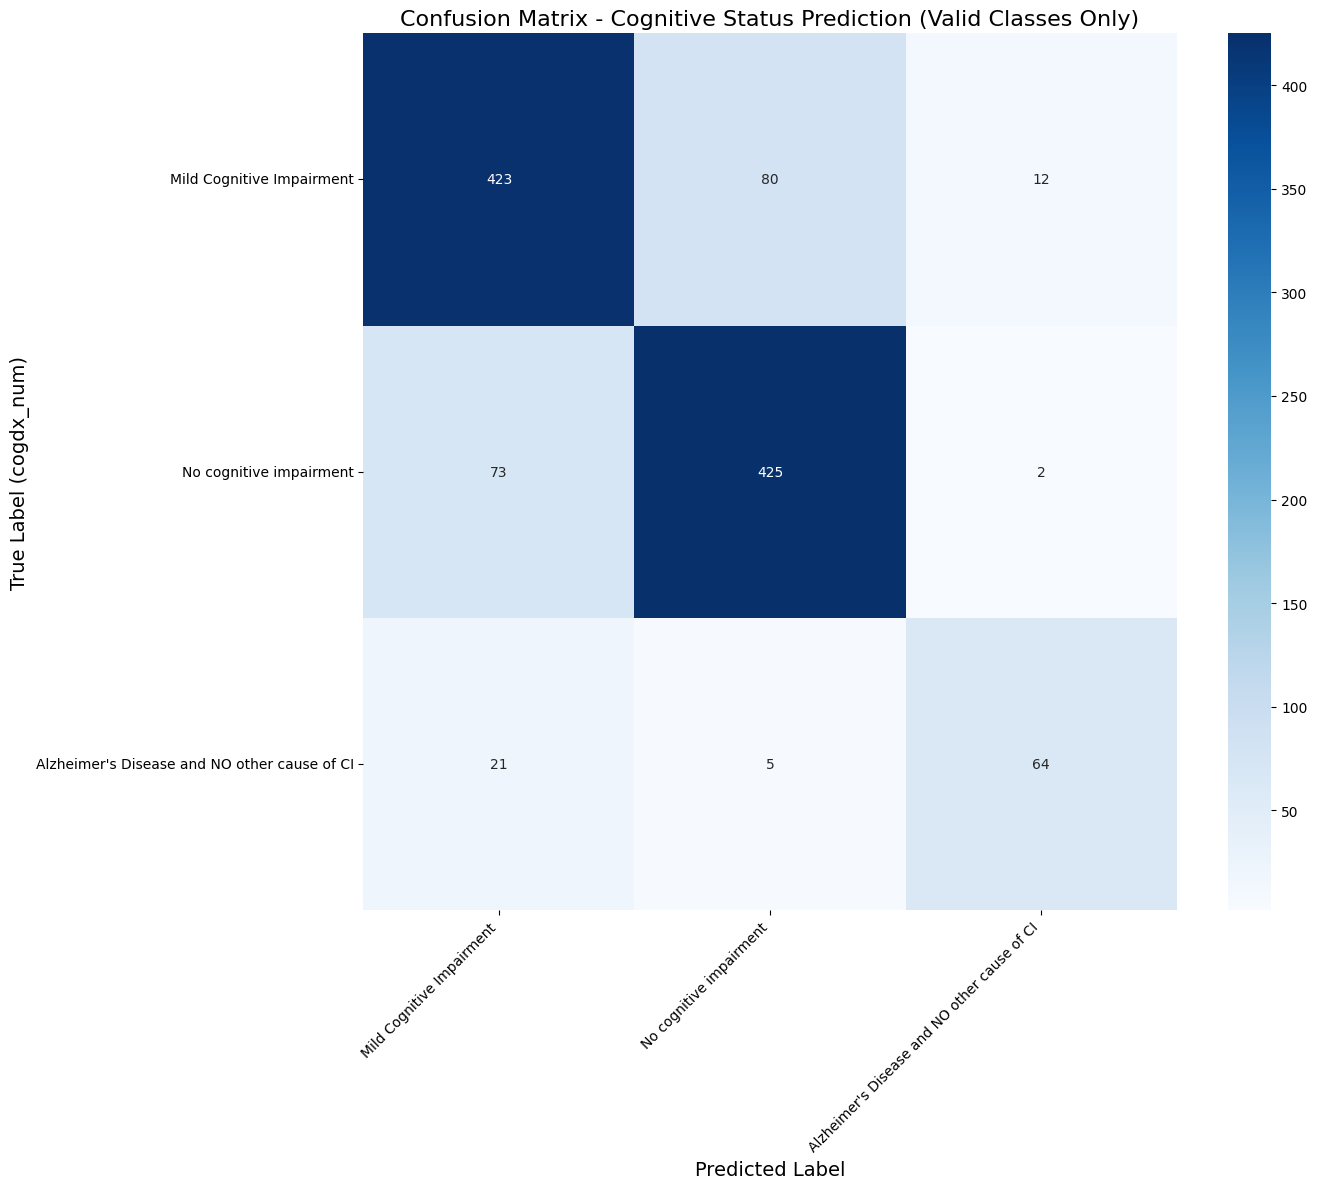


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.82      0.82      0.82       517
                     No cognitive impairment       0.83      0.85      0.84       500
Alzheimer's Disease and NO other cause of CI       0.82      0.71      0.76        90

                                   micro avg       0.83      0.82      0.82      1107
                                   macro avg       0.82      0.79      0.81      1107
                                weighted avg       0.83      0.82      0.82      1107


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.818182  0.818182  0.818182   
No cognitive impairment                        0.833333  0.850000  0.841584   
Alzheimer's Disease and NO other cause of CI   0.820513  0.711111  0.761905   
micro

In [6]:
##ROS_MAP2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

# Corrected file path - use absolute path with home directory
file_path = os.path.expanduser("~/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Full_Model_With_DERs_ADNI_othern_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx_num']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx_num'] = df['cogdx_num'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx_num'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx_num'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx_num'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx_num']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label (cogdx_num)', fontsize=14)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx_num'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx_num']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx_num']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx_num', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx_num'], f'Unknown ({row["cogdx_num"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")




File found at: /Users/martinnwadiugwu/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Reduced_Model_No_DERs_ADNI_othern_labeled.csv

Data Preview:
   ID       Age  race_Black_or_AA   race_HW  race_Asian  race_Other  race_NHW  \
0   2 -0.222797         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   
1   7 -0.105537         -0.180579 -0.141204    -0.11713   -0.077791 -3.507136   
2  15  0.475086         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   
3  21 -0.417561          5.537749 -0.141204    -0.11713   -0.077791 -3.507136   
4  30  0.382367         -0.180579 -0.141204    -0.11713   -0.077791  0.285133   

   race_unknown    PMI.h.     KCNH8  ...     PC_29     PC_30         PC_31  \
0     -0.103142  0.236911  0.236576  ...  0.143802  0.079604 -5.400000e-16   
1      9.695360 -1.304814  0.397417  ...  0.016383 -0.033074  5.529798e-16   
2     -0.103142  0.838384 -0.433381  ...  0.061272  0.066042 -5.450000e-16   
3     -0.103142  1.384111  0.236576  .

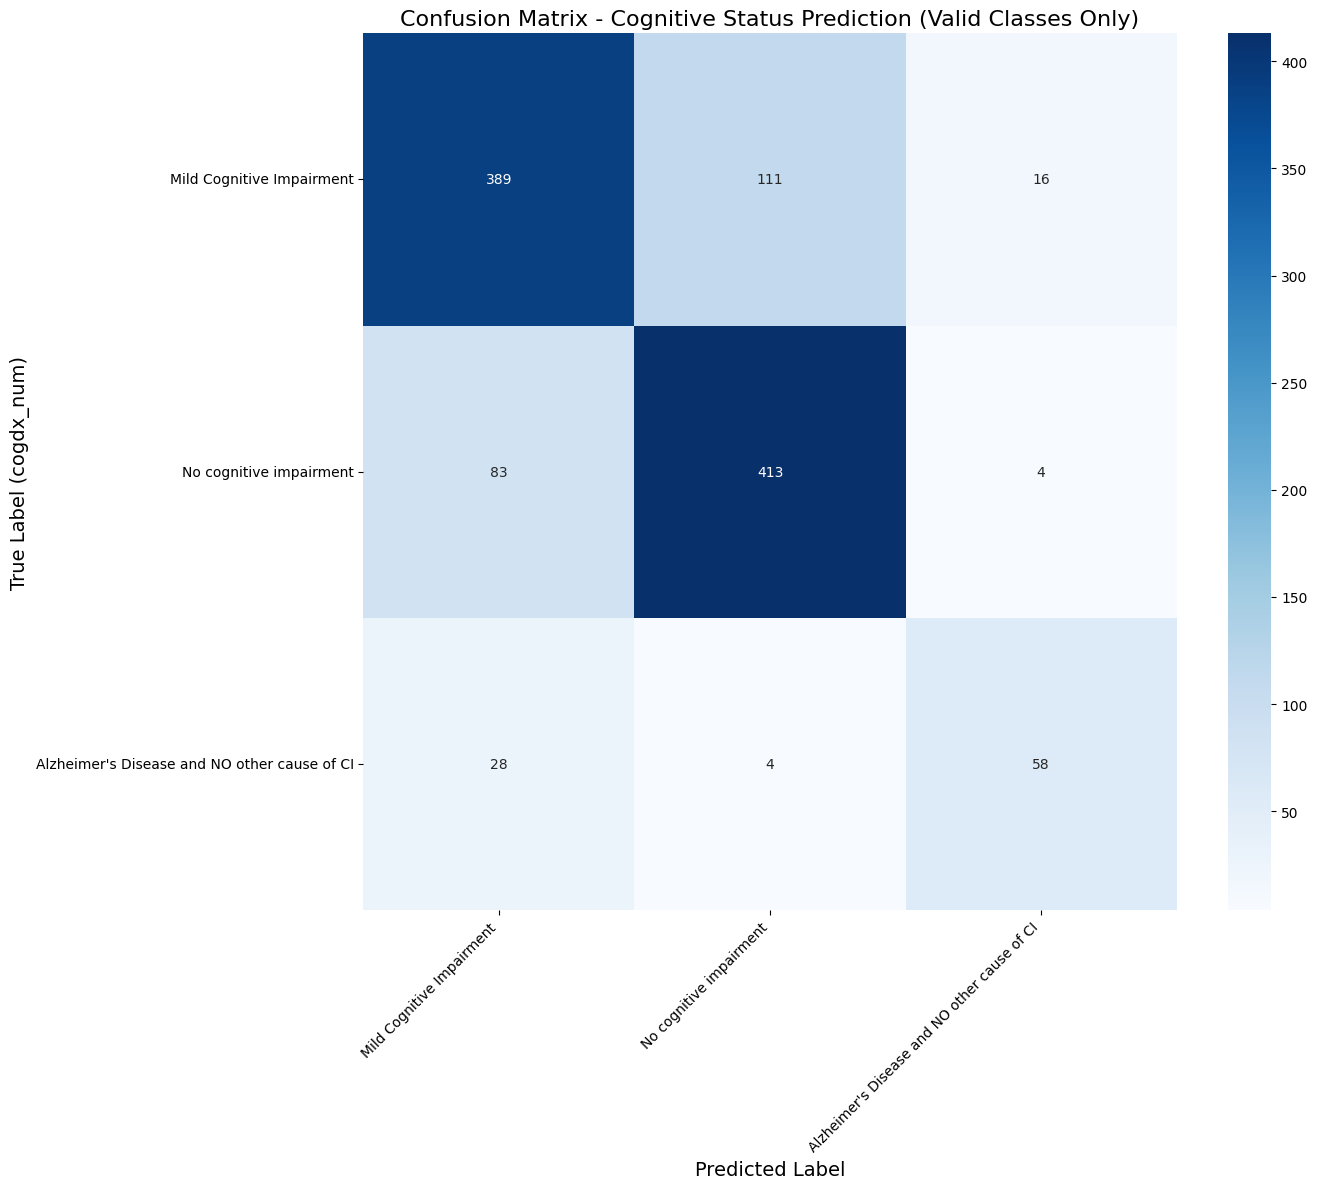


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.78      0.75      0.76       517
                     No cognitive impairment       0.78      0.83      0.80       500
Alzheimer's Disease and NO other cause of CI       0.74      0.64      0.69        90

                                   micro avg       0.78      0.78      0.78      1107
                                   macro avg       0.77      0.74      0.75      1107
                                weighted avg       0.78      0.78      0.78      1107


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.778000  0.752418  0.764995   
No cognitive impairment                        0.782197  0.826000  0.803502   
Alzheimer's Disease and NO other cause of CI   0.743590  0.644444  0.690476   
micro

In [7]:
##ROS_MAP2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

# Corrected file path - use absolute path with home directory
file_path = os.path.expanduser("~/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Reduced_Model_No_DERs_ADNI_othern_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx_num']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx_num'] = df['cogdx_num'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx_num'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx_num'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx_num'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx_num']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label (cogdx_num)', fontsize=14)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx_num'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx_num']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx_num']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx_num', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx_num'], f'Unknown ({row["cogdx_num"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")




File found at: /Users/martinnwadiugwu/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Full_Model_With_DERs_ROS_MAP2_labeled.csv

Data Preview:
         ID       Age  race_Black_or_AA   race_HW  race_Asian  race_Other  \
0  10100574  0.738451         -0.180579 -0.141204    -0.11713   -0.077791   
1  10101589  1.407193         -0.180579 -0.141204    -0.11713   -0.077791   
2  10202345  0.534327         -0.180579 -0.141204    -0.11713   -0.077791   
3  10203224  0.673758         -0.180579 -0.141204    -0.11713   -0.077791   
4  10205244  0.649221         -0.180579 -0.141204    -0.11713   -0.077791   

   race_NHW  race_unknown    PMI.h.     KCNH8  ...     PC_33     PC_34  \
0  0.285133     -0.103142  1.267400  0.536784  ... -0.471983  0.076374   
1  0.285133     -0.103142  0.739426  0.331857  ...  0.630057 -0.031590   
2  0.285133     -0.103142  0.268360  0.536784  ...  0.048753  0.068368   
3  0.285133     -0.103142  0.615230  0.536784  ...  0.053806  0.004102   
4  0.285

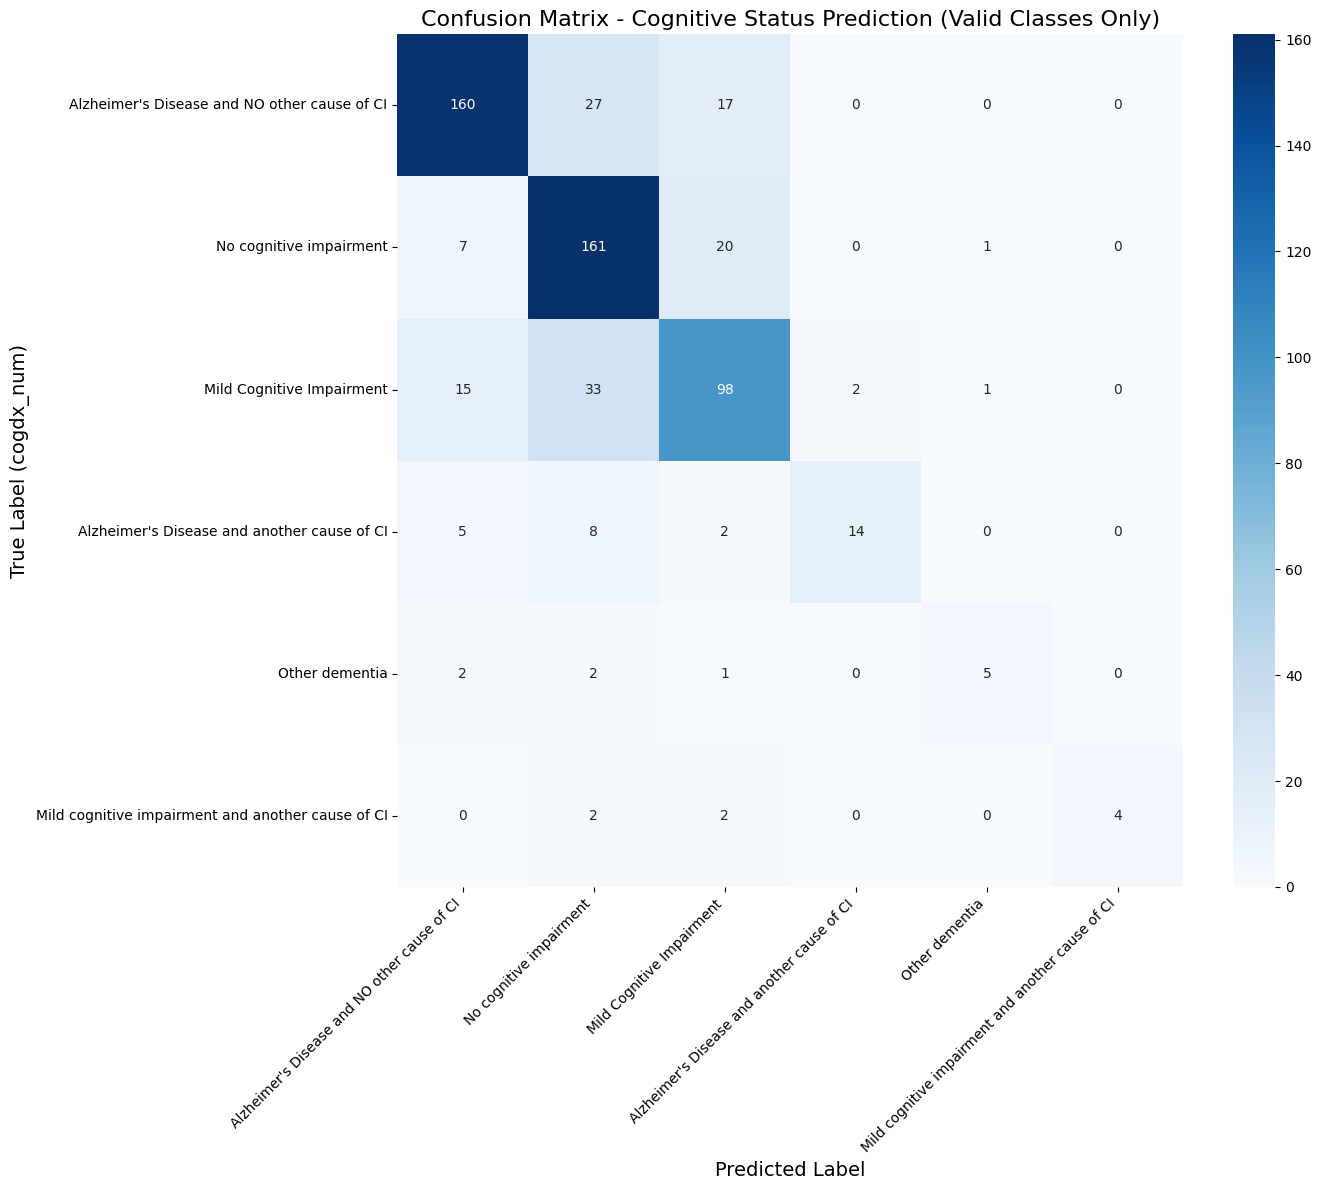


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.85      0.78      0.81       204
                          No cognitive impairment       0.69      0.85      0.76       189
                        Mild Cognitive Impairment       0.70      0.66      0.68       149
      Alzheimer's Disease and another cause of CI       0.88      0.48      0.62        29
                                   Other dementia       0.71      0.50      0.59        10
Mild cognitive impairment and another cause of CI       1.00      0.50      0.67         8

                                         accuracy                           0.75       589
                                        macro avg       0.80      0.63      0.69       589
                                     weighted avg       0.76      0.75      0.75       589


Metrics DataFrame:
             

In [8]:
##ROS_MAP2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

# Corrected file path - use absolute path with home directory
file_path = os.path.expanduser("~/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Full_Model_With_DERs_ROS_MAP2_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx_num']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx_num'] = df['cogdx_num'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx_num'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx_num'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx_num'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx_num']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label (cogdx_num)', fontsize=14)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx_num'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx_num']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx_num']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx_num', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx_num'], f'Unknown ({row["cogdx_num"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")




File found at: /Users/martinnwadiugwu/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Reduced_Model_No_DERs_ROS_MAP2_labeled.csv

Data Preview:
         ID       Age  race_Black_or_AA   race_HW  race_Asian  race_Other  \
0  10100574  0.738451         -0.180579 -0.141204    -0.11713   -0.077791   
1  10101589  1.407193         -0.180579 -0.141204    -0.11713   -0.077791   
2  10202345  0.534327         -0.180579 -0.141204    -0.11713   -0.077791   
3  10203224  0.673758         -0.180579 -0.141204    -0.11713   -0.077791   
4  10205244  0.649221         -0.180579 -0.141204    -0.11713   -0.077791   

   race_NHW  race_unknown    PMI.h.     KCNH8  ...     PC_29     PC_30  \
0  0.285133     -0.103142  1.267400  0.536784  ... -0.466572  0.081199   
1  0.285133     -0.103142  0.739426  0.331857  ...  0.648093 -0.025296   
2  0.285133     -0.103142  0.268360  0.536784  ...  0.061624  0.066483   
3  0.285133     -0.103142  0.615230  0.536784  ...  0.054058  0.003943   
4  0.28

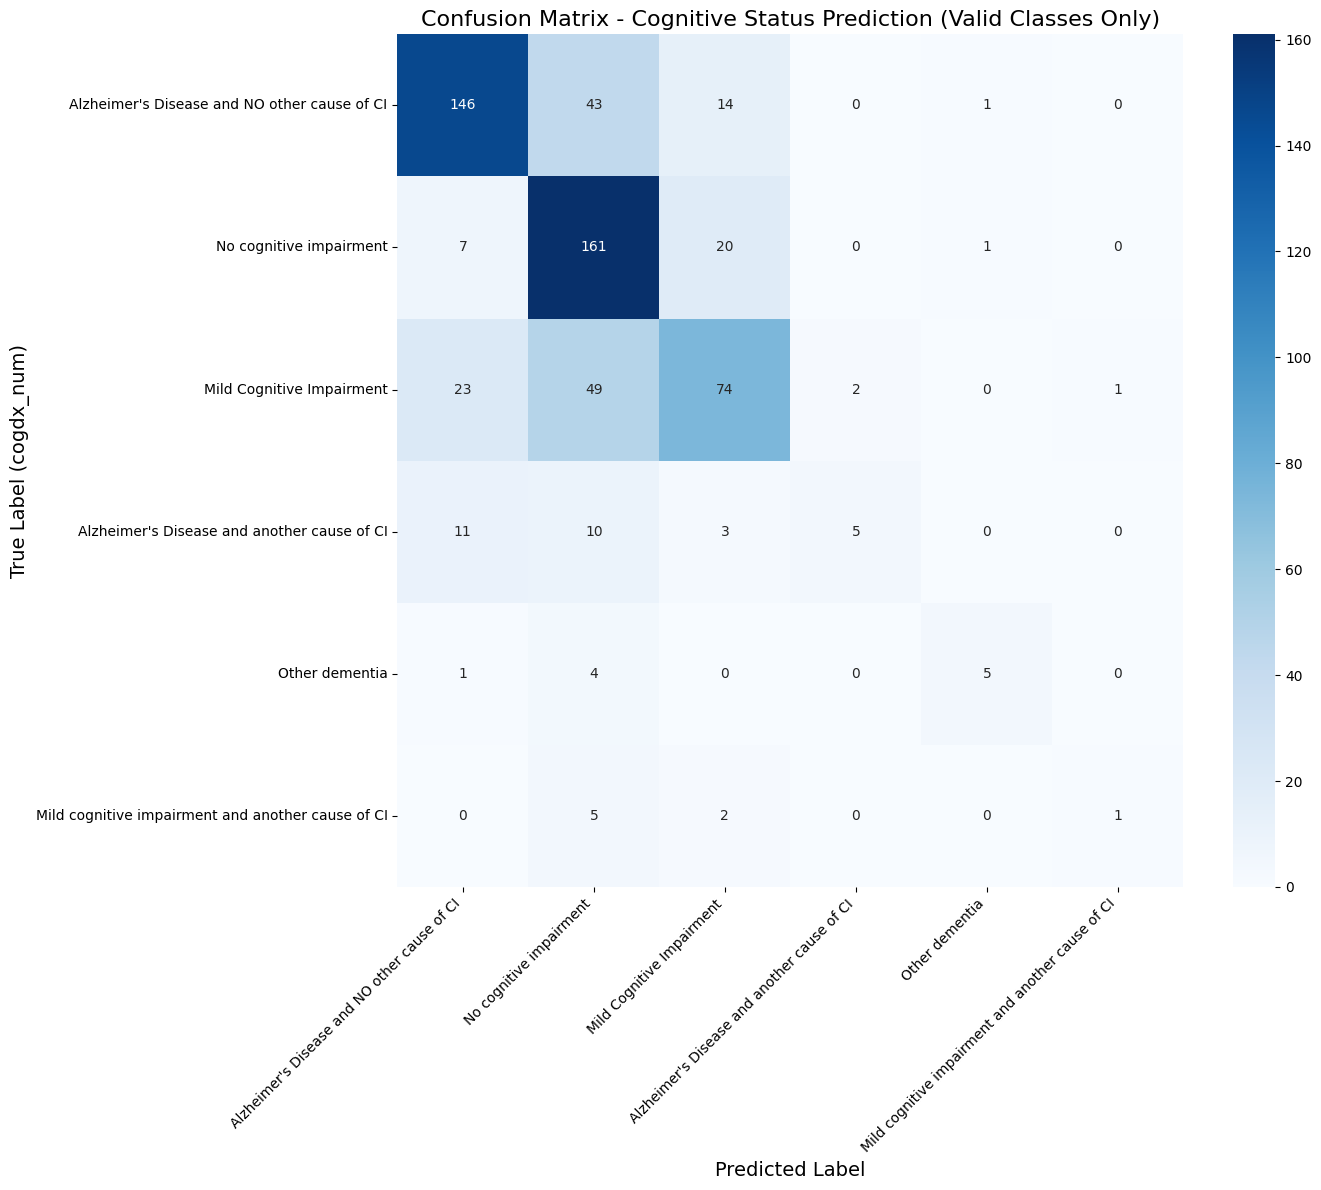


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.78      0.72      0.74       204
                          No cognitive impairment       0.59      0.85      0.70       189
                        Mild Cognitive Impairment       0.65      0.50      0.56       149
      Alzheimer's Disease and another cause of CI       0.71      0.17      0.28        29
                                   Other dementia       0.71      0.50      0.59        10
Mild cognitive impairment and another cause of CI       0.50      0.12      0.20         8

                                         accuracy                           0.67       589
                                        macro avg       0.66      0.48      0.51       589
                                     weighted avg       0.68      0.67      0.65       589


Metrics DataFrame:
             

In [9]:
##ROS_MAP2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

# Corrected file path - use absolute path with home directory
file_path = os.path.expanduser("~/Downloads/cogdx_results_singletrain0.4_testn_2/test_predictions_Reduced_Model_No_DERs_ROS_MAP2_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx_num']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx_num'] = df['cogdx_num'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx_num'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx_num'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx_num'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx_num']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label (cogdx_num)', fontsize=14)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.show()
        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx_num'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx_num'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx_num']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx_num']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx_num', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx_num'], f'Unknown ({row["cogdx_num"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")





ADNI: DER vs No DER for Total Misclassifications of Class 1 (CN)
Observed:
[[ 73 428]
 [ 87 414]]
Chi² p = 0.2648, Fisher p = 0.2648

ROSMAP: DER vs No DER for Total Misclassifications of Class 1 (CN)
Observed:
[[ 20 169]
 [ 20 169]]
Chi² p = 1.0000, Fisher p = 1.0000

ADNI: DER vs No DER for Total Misclassifications of Class 2 (MCI)
Observed:
[[ 92 425]
 [127 390]]
Chi² p = 0.0099, Fisher p = 0.0098

ROSMAP: DER vs No DER for Total Misclassifications of Class 2 (MCI)
Observed:
[[ 48 101]
 [ 72  77]]
Chi² p = 0.0070, Fisher p = 0.0069

ADNI: DER vs No DER for Total Misclassifications of Class 4 (AD)
Observed:
[[26 64]
 [28 62]]
Chi² p = 0.8727, Fisher p = 0.8728

ROSMAP: DER vs No DER for Total Misclassifications of Class 4 (AD)
Observed:
[[ 44 160]
 [ 57 147]]
Chi² p = 0.1722, Fisher p = 0.1720

Corrected p-values (FDR):
ADNI: DER vs No DER for Total Misclassifications of Class 1 (CN): p = 0.3972
ROSMAP: DER vs No DER for Total Misclassifications of Class 1 (CN): p = 1.0000
ADNI: DER

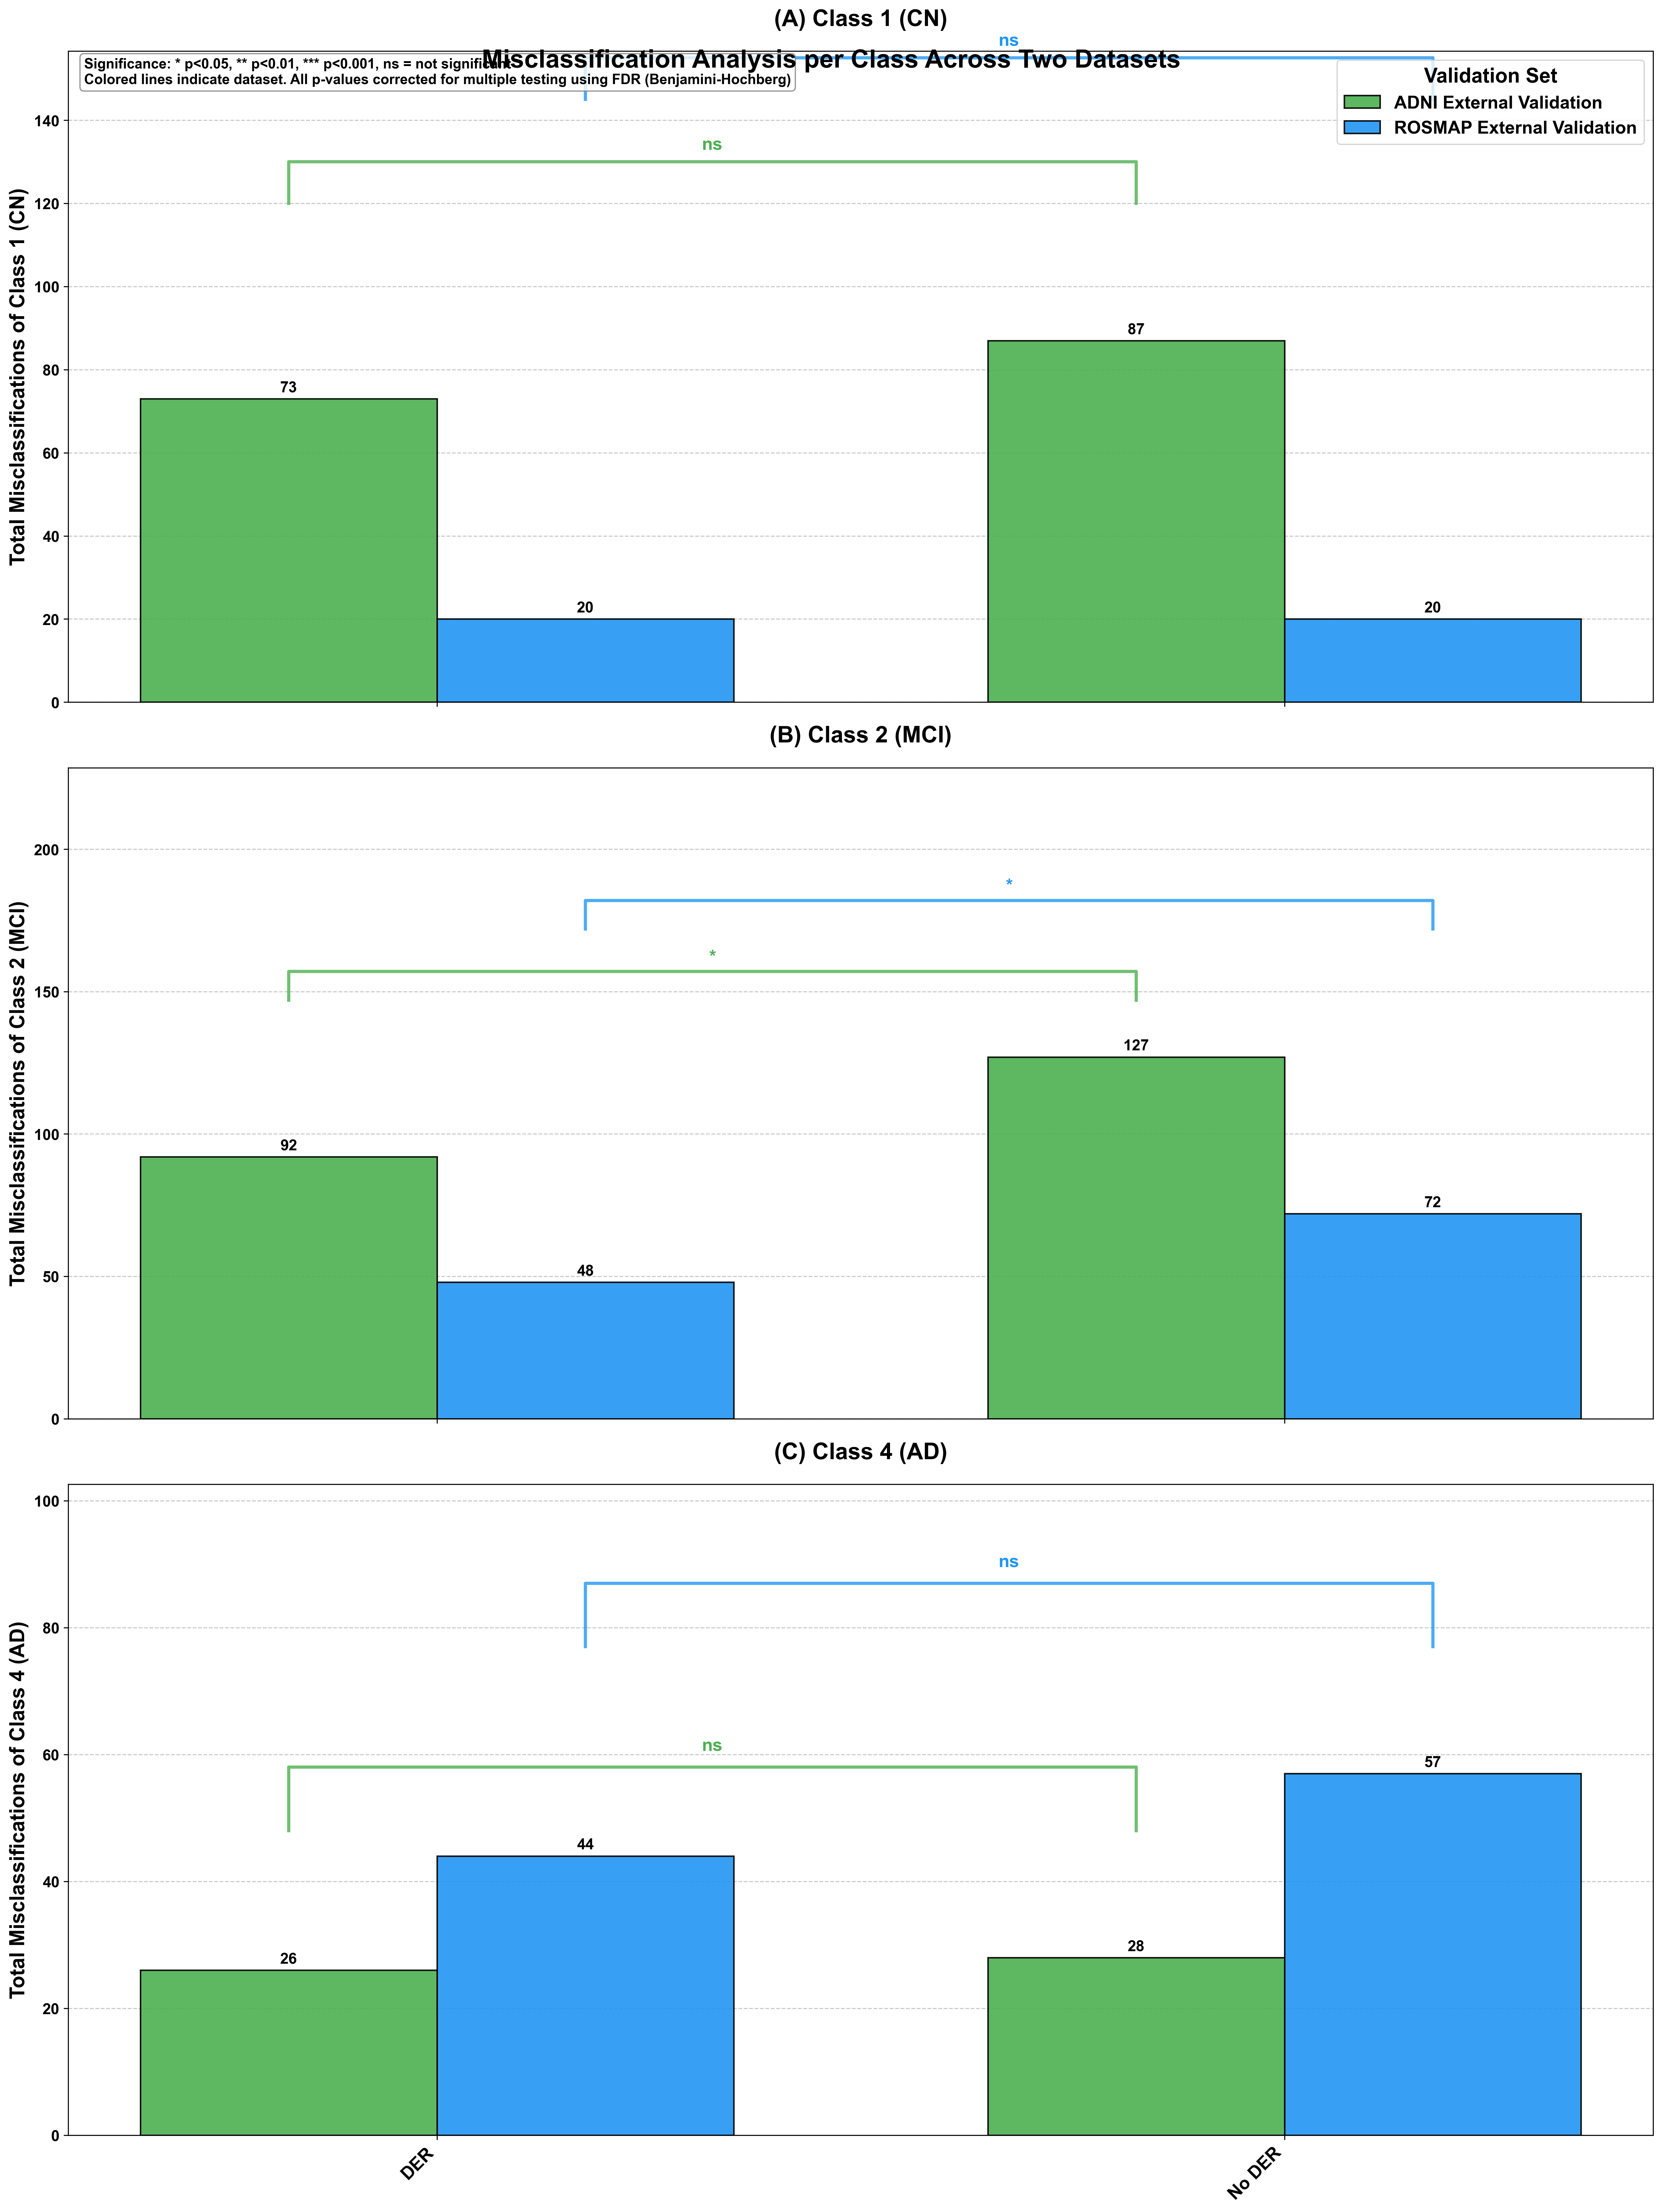


SUMMARY STATISTICS

Class 1:
  ADNI - With DERs: 73, Without DERs: 87, Improvement: 14
  ROSMAP - With DERs: 20, Without DERs: 20, Improvement: 0

Class 2:
  ADNI - With DERs: 92, Without DERs: 127, Improvement: 35
  ROSMAP - With DERs: 48, Without DERs: 72, Improvement: 24

Class 4:
  ADNI - With DERs: 26, Without DERs: 28, Improvement: 2
  ROSMAP - With DERs: 44, Without DERs: 57, Improvement: 13


In [1]:
#misclassification_analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl

# Set publication-quality style
plt.style.use('default')
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['savefig.bbox'] = 'tight'

# -------------------------------
# Configuration
# -------------------------------
PAIRS_TO_COMPARE = [
    ("DER", "No DER")
]

# Define model order for each dataset using abbreviations
ADNI_ORDER = ["DER", "No DER"]
ROSMAP_ORDER = ["DER", "No DER"]

# Mapping from full names to abbreviations
FULL_TO_ABBREV = {
    "With DERs": "DER",
    "Without DERs": "No DER"
}

# Total number of samples for each class
ADNI_TOTALS = {
    "Class 1": 501,
    "Class 2": 517,
    "Class 3": 0,
    "Class 4": 90
}

ROSMAP_TOTALS = {
    "Class 1": 189,
    "Class 2": 149,
    "Class 3": 8,
    "Class 4": 204,
    "Class 5": 29,
    "Class 6": 10
}

# Dictionary to store the y-level for significance bars for each subplot
placed_bars_per_ax = {}

# -------------------------------
# Helper functions
# -------------------------------
def clean_model_name(col_name):
    """
    Cleans up the DataFrame column name to match the model order.
    Example: ' "With DERs\n(ADNI External Validation 1)" ' -> 'With DERs'
    """
    name = col_name.split('\n')[0].strip(' "')
    return FULL_TO_ABBREV.get(name, name)

def significance_stars(p):
    """Convert p-value into significance stars."""
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

def run_tests(contingency_table, label):
    """Perform Chi² and Fisher's exact tests if possible."""
    results = {}
    # Chi² test (add small value to avoid zero expected frequencies)
    contingency_table_clean = contingency_table + 1
    chi2, p_chi2, dof, expected = chi2_contingency(contingency_table_clean)
    results["chi2_p"] = p_chi2

    # Fisher's exact (only valid for 2x2)
    if contingency_table.shape == (2, 2):
        _, p_fisher = fisher_exact(contingency_table_clean)
        results["fisher_p"] = p_fisher
    else:
        results["fisher_p"] = np.nan

    print(f"\n{label}")
    print("Observed:")
    print(contingency_table)
    print(f"Chi² p = {p_chi2:.4f}, Fisher p = {results['fisher_p']:.4f}" if not np.isnan(results['fisher_p']) else f"Chi² p = {p_chi2:.4f}")

    return results

def add_significance_bar(ax, x1, x2, y_max, p_corrected, color, specific_y=None):
    """
    Adds a significance bar with a dynamic vertical offset.
    Can be overridden with a specific y-coordinate.
    """
    global placed_bars_per_ax
    if ax not in placed_bars_per_ax:
        placed_bars_per_ax[ax] = []

    star = significance_stars(p_corrected)
    height = 10
    vertical_spacing = 15
    
    if specific_y is not None:
        y_start = specific_y
    else:
        y_start = y_max + 20
        # Dynamic calculation for all other bars
        for placed_bar in placed_bars_per_ax[ax]:
            placed_x1, placed_x2, placed_y_end = placed_bar
            # Check for overlap and adjust the y position
            if (min(x1, x2) < max(placed_x1, placed_x2)) and (max(x1, x2) > min(placed_x1, placed_x2)):
                y_start = max(y_start, placed_y_end + vertical_spacing)

    # Plot the bar and the stars
    ax.plot([x1, x1, x2, x2], [y_start, y_start + height, y_start + height, y_start],
            lw=2.5, c=color, alpha=0.8)
    ax.text((x1 + x2) / 2, y_start + height * 1.2, star, ha='center', va='bottom',
            fontsize=14, fontweight='bold', color=color)

    # Store the coordinates of the new bar to prevent future overlaps
    placed_bars_per_ax[ax].append((min(x1, x2), max(x1, x2), y_start + height))

# -------------------------------
# Data (Corrected)
# -------------------------------
data = {
    'Metric': [
        'Misclassified Class 5 as Class 1', 'Misclassified Class 4 as Class 1',
        'Misclassified Class 4 as Class 2', 'Misclassified Class 4 as Class 3',
        'Misclassified Class 4 as Class 5', 'Misclassified Class 4 as Class 6',
        'Misclassified Class 3 as Class 1', 'Misclassified Class 3 as Class 2',
        'Misclassified Class 3 as Class 4', 'Misclassified Class 2 as Class 4',
        'Misclassified Class 2 as Class 3', 'Misclassified Class 2 as Class 5',
        'Misclassified Class 2 as Class 6', 'Misclassified Class 2 as Class 1',
        'Misclassified Class 1 as Class 4', 'Misclassified Class 1 as Class 3',
        'Misclassified Class 1 as Class 2', 'Misclassified Class 1 as Class 6'
    ],

    # --- ADNI External Validation 1 ---
    '"With DERs\n(ADNI External Validation 1)"': [
        0, 5, 21, 0, 0, 0, 0, 0, 0,
        12, 0, 0, 0, 80,
        0, 0, 73, 0
    ],
    '"Without DERs\n(ADNI External Validation 1)"': [
        0, 0, 28, 0, 0, 0, 0, 0, 0,
        16, 0, 0, 0, 111,
        4, 0, 83, 0
    ],

    # --- ROSMAP External Validation 2 ---
    '"With DERs\n(ROSMAP External Validation 2)"': [
        0, 27, 17, 0, 0, 0, 0, 0, 0,
        15, 0, 0, 0, 33,
        0, 0, 20, 0
    ],
    '"Without DERs\n(ROSMAP External Validation 2)"': [
        0, 43, 14, 0, 0, 0, 0, 0, 0,
        23, 0, 0, 0, 49,
        0, 0, 20, 0
    ]
}

df = pd.DataFrame(data).set_index('Metric')

# Define misclassification metrics for each class
class1_misclassifications = [
    'Misclassified Class 1 as Class 4',
    'Misclassified Class 1 as Class 3',
    'Misclassified Class 1 as Class 2',
    'Misclassified Class 1 as Class 6'
]

class2_misclassifications = [
    'Misclassified Class 2 as Class 4',
    'Misclassified Class 2 as Class 3',
    'Misclassified Class 2 as Class 5',
    'Misclassified Class 2 as Class 6',
    'Misclassified Class 2 as Class 1'
]

class4_misclassifications = [
    'Misclassified Class 4 as Class 1',
    'Misclassified Class 4 as Class 2',
    'Misclassified Class 4 as Class 3',
    'Misclassified Class 4 as Class 5',
    'Misclassified Class 4 as Class 6'
]

# -------------------------------
# Plotting setup with constrained layout
# -------------------------------
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 24), sharex=True, 
                       constrained_layout=True)  # Use constrained_layout instead
plt.suptitle("Misclassification Analysis per Class Across Two Datasets",
             fontsize=20, fontweight='bold', y=0.98)

width = 0.35
x_adni = np.arange(len(ADNI_ORDER))
x_rosmap = np.arange(len(ROSMAP_ORDER))

# Lists to hold all p-values and test info for combined FDR correction
all_pvals = []
all_test_info = []

# Loop through each class and create a subplot
for i, (class_metrics, class_name, class_label, total_adni, total_rosmap) in enumerate([
    (class1_misclassifications, "Class 1 (CN)", "Total Misclassifications of Class 1 (CN)", ADNI_TOTALS["Class 1"], ROSMAP_TOTALS["Class 1"]),
    (class2_misclassifications, "Class 2 (MCI)", "Total Misclassifications of Class 2 (MCI)", ADNI_TOTALS["Class 2"], ROSMAP_TOTALS["Class 2"]),
    (class4_misclassifications, "Class 4 (AD)", "Total Misclassifications of Class 4 (AD)", ADNI_TOTALS["Class 4"], ROSMAP_TOTALS["Class 4"])
]):
    ax = axs[i]

    totals = df.loc[class_metrics].sum()

    adni_clean_to_original = {clean_model_name(col): col for col in df.columns if 'ADNI' in col}
    rosmap_clean_to_original = {clean_model_name(col): col for col in df.columns if 'ROSMAP' in col}
    
    adni_values = [totals.get(adni_clean_to_original.get(name), 0) for name in ADNI_ORDER]
    rosmap_values = [totals.get(rosmap_clean_to_original.get(name), 0) for name in ROSMAP_ORDER]

    # Create bars
    rects1 = ax.bar(x_adni - width/2, adni_values, width, label="ADNI External Validation", 
                    color="#4CAF50", alpha=0.9, edgecolor='black', linewidth=1.2)
    rects2 = ax.bar(x_rosmap + width/2, rosmap_values, width, label="ROSMAP External Validation", 
                    color="#2196F3", alpha=0.9, edgecolor='black', linewidth=1.2)

    # Add value labels
    for rects in [rects1, rects2]:
        for rect in rects:
            h = rect.get_height()
            ax.annotate(f"{int(h)}", xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=12, fontweight='bold')

    # Set subplot labels and title
    ax.set_ylabel(class_label, fontsize=16, fontweight='bold')
    ax.set_title(f"({chr(65+i)}) {class_name}", fontsize=18, fontweight='bold', pad=20)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    # Set y-limits to accommodate significance bars
    max_bar_value = max(max(adni_values), max(rosmap_values))
    ax.set_ylim(0, max_bar_value * 1.8)  # Increased space for significance bars

    # Statistical tests for the current subplot
    for pair_name_1, pair_name_2 in PAIRS_TO_COMPARE:
        idx1_adni = ADNI_ORDER.index(pair_name_1) if pair_name_1 in ADNI_ORDER else None
        idx2_adni = ADNI_ORDER.index(pair_name_2) if pair_name_2 in ADNI_ORDER else None
        
        idx1_rosmap = ROSMAP_ORDER.index(pair_name_1) if pair_name_1 in ROSMAP_ORDER else None
        idx2_rosmap = ROSMAP_ORDER.index(pair_name_2) if pair_name_2 in ROSMAP_ORDER else None

        if idx1_adni is not None and idx2_adni is not None:
            val1 = adni_values[idx1_adni]
            val2 = adni_values[idx2_adni]
            
            if val1 is not None and val2 is not None:
                contingency_table = np.array([
                    [val1, total_adni - val1],
                    [val2, total_adni - val2]
                ])
                res = run_tests(contingency_table, f"ADNI: {pair_name_1} vs {pair_name_2} for {class_label}")
                all_pvals.append(res["chi2_p"])
                all_test_info.append({
                    "ax": ax,
                    "x_positions": (idx1_adni - width/2, idx2_adni - width/2),
                    "max_val": max(val1, val2),
                    "color": "#4CAF50",
                    "label": f"ADNI: {pair_name_1} vs {pair_name_2} for {class_label}"
                })
        
        if idx1_rosmap is not None and idx2_rosmap is not None:
            val1 = rosmap_values[idx1_rosmap]
            val2 = rosmap_values[idx2_rosmap]
            
            if val1 is not None and val2 is not None:
                contingency_table = np.array([
                    [val1, total_rosmap - val1],
                    [val2, total_rosmap - val2]
                ])
                res = run_tests(contingency_table, f"ROSMAP: {pair_name_1} vs {pair_name_2} for {class_label}")
                all_pvals.append(res["chi2_p"])
                all_test_info.append({
                    "ax": ax,
                    "x_positions": (idx1_rosmap + width/2, idx2_rosmap + width/2),
                    "max_val": max(val1, val2),
                    "color": "#2196F3",
                    "label": f"ROSMAP: {pair_name_1} vs {pair_name_2} for {class_label}"
                })

# -------------------------------
# Final plot adjustments
# -------------------------------
axs[0].legend(title="Validation Set", fontsize=14, title_fontsize=16, loc='upper right')
axs[-1].set_xticks(x_adni)
axs[-1].set_xticklabels(ADNI_ORDER, rotation=45, ha="right", fontsize=14, fontweight='bold')

# -------------------------------
# Multiple testing correction and dynamic plotting
# -------------------------------
if all_pvals:
    rej, pvals_corrected, _, _ = multipletests(all_pvals, method='fdr_bh')
    print("\nCorrected p-values (FDR):")
    
    # Store corrected p-values and sort tests
    for i, test in enumerate(all_test_info):
        test["p_corrected"] = pvals_corrected[i]
        print(f"{test['label']}: p = {pvals_corrected[i]:.4f}")
    
    # Sort by the x-position to ensure the dynamic offset works correctly
    all_test_info.sort(key=lambda x: min(x["x_positions"]))
    
    # Plot significance bars with dynamic offset
    for test in all_test_info:
        # Check for the specific request and use the hardcoded value
        if test["label"] == "ADNI: DER vs No DER for Total Misclassifications of Class 1 (CN)":
            add_significance_bar(
                ax=test["ax"],
                x1=test["x_positions"][0],
                x2=test["x_positions"][1],
                y_max=test["max_val"],
                p_corrected=test["p_corrected"],
                color=test["color"],
                specific_y=120 # Hardcoded value as requested
            )
        else:
            add_significance_bar(
                ax=test["ax"],
                x1=test["x_positions"][0],
                x2=test["x_positions"][1],
                y_max=test["max_val"],
                p_corrected=test["p_corrected"],
                color=test["color"]
            )

# Add significance legend note with FDR information
axs[0].text(
    0.01, 0.99,
    "Significance: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant\n"
    "Colored lines indicate dataset. All p-values corrected for multiple testing using FDR (Benjamini-Hochberg)",
    transform=axs[0].transAxes, fontsize=11, va='top', ha='left', fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Remove the tight_layout call since we're using constrained_layout
plt.savefig('/Users/martinnwadiugwu/Downloads/combined_misclassification_plot_fdr_corrected.pdf', dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for class_name, class_metrics in [("Class 1", class1_misclassifications), 
                                  ("Class 2", class2_misclassifications), 
                                  ("Class 4", class4_misclassifications)]:
    totals = df.loc[class_metrics].sum()
    
    adni_with = totals['"With DERs\n(ADNI External Validation 1)"']
    adni_without = totals['"Without DERs\n(ADNI External Validation 1)"']
    rosmap_with = totals['"With DERs\n(ROSMAP External Validation 2)"']
    rosmap_without = totals['"Without DERs\n(ROSMAP External Validation 2)"']
    
    print(f"\n{class_name}:")
    print(f"  ADNI - With DERs: {adni_with}, Without DERs: {adni_without}, Improvement: {adni_without - adni_with}")
    print(f"  ROSMAP - With DERs: {rosmap_with}, Without DERs: {rosmap_without}, Improvement: {rosmap_without - rosmap_with}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

# -------------------------------
# Publication-quality style
# -------------------------------
plt.style.use('default')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['savefig.bbox'] = 'tight'

# -------------------------------
# Data
# -------------------------------
data = {
    'Predicted Cogdx': [
        'Class 1 (No CI)',
        'Class 2 (MCI)',
        'Class 3 (MCI & another cause of CI)',
        'Class 4 (AD & No other cause of CI)',
        'Class 5 (AD & another cause of CI)',
        'Class 6 (Other dementia)',
        'Total cases'
    ],
    'Control (DER)': [7, 0, 0, 1, 0, 0, 8],
    'AD (DER)': [3, 1, 1, 13, 0, 0, 18],
    'Control (No DER)': [6, 2, 0, 0, 0, 0, 8],
    'AD (No DER)': [4, 3, 1, 10, 0, 0, 18]
}

df = pd.DataFrame(data).set_index('Predicted Cogdx')

# -------------------------------
# Model configuration
# -------------------------------
model_info = [
    {'name': '(A) DER', 'control_col': 'Control (DER)', 'ad_col': 'AD (DER)'},
    {'name': '(B) No DER', 'control_col': 'Control (No DER)', 'ad_col': 'AD (No DER)'}
]

# -------------------------------
# Custom colormap
# -------------------------------
colors = ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6",
          "#4292c6", "#2171b5", "#08519c", "#08306b"]
cmap = LinearSegmentedColormap.from_list("custom_blue", colors, N=256)

# -------------------------------
# Figure layout
# -------------------------------
fig, axs = plt.subplots(1, 2, figsize=(22, 10))
plt.suptitle(
    'Classification Performance Across Different Models\n(Control vs AD Cases)',
    fontsize=22,
    fontweight='bold',
    y=0.98
)

axs = axs.flatten()

# -------------------------------
# Plot for each model
# -------------------------------
for i, model in enumerate(model_info):
    ax = axs[i]

    control_data = df[model['control_col']].values[:-1]  # exclude total row
    ad_data = df[model['ad_col']].values[:-1]

    heatmap_data = np.array([control_data, ad_data])

    # Heatmap itself
    im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=0, vmax=20)

    # Value annotations
    for j in range(2):          # Control, AD
        for k in range(6):      # Classes 1–6
            value = heatmap_data[j, k]
            text_color = 'white' if value > 10 else 'black'
            ax.text(k, j, f'{int(value)}', ha='center', va='center',
                    fontsize=16, fontweight='bold', color=text_color)

    # Axes formatting
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'Class {ii+1}' for ii in range(6)],
                       rotation=45, ha='right')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Control', 'AD'])

    # Accuracy calculation
    correct_control = heatmap_data[0, 0]   # Class 1 for Control
    correct_ad = heatmap_data[1, 3]        # Class 4 for AD
    total_cases = df[model['control_col']]['Total cases'] + df[model['ad_col']]['Total cases']

    accuracy = (correct_control + correct_ad) / total_cases * 100

    ax.set_title(f'{model["name"]}\nAccuracy: {accuracy:.1f}%',
                 fontsize=18, fontweight='bold', pad=15)

    # Gridlines
    ax.set_xticks(np.arange(-0.5, 6, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.3)

    # Highlight correct predictions
    # Control = Class 1 → (x=0), row=0
    rect_control = patches.Rectangle(
        (-0.5, -0.5), 1, 1,
        linewidth=3, edgecolor='green',
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect_control)

    # AD = Class 4 → index 3, row=1
    rect_ad = patches.Rectangle(
        (3 - 0.5, 1 - 0.5), 1, 1,
        linewidth=3, edgecolor='green',
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect_ad)

# -------------------------------
# Colorbar
# -------------------------------
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Number of Cases', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# -------------------------------
# Legend
# -------------------------------
legend_elements = [
    patches.Patch(
        facecolor='none', edgecolor='green',
        linestyle='--', linewidth=3,
        label='Correct Classification'
    )
]
fig.legend(
    handles=legend_elements,
    loc='center right',
    bbox_to_anchor=(0.0, 0.5),
    fontsize=12,
    title='Legend',
    title_fontsize=16
)

# -------------------------------
# Explanatory footer text
# -------------------------------
fig.text(
    0.5, -0.03,
    'Note: Correct classifications are highlighted with green dashed boxes.\n'
    'For Control cases, correct prediction is Class 1 (No CI).\n'
    'For AD cases, correct prediction is Class 4 (AD & No other cause of CI).',
    ha='center', fontsize=12, style='italic',
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

# -------------------------------

# Layout and save
# -------------------------------
plt.subplots_adjust(left=0.05, right=0.9, top=0.9, bottom=0.12, wspace=0.25)

plt.savefig('/Users/martinnwadiugwu/Downloads/model_comparison_heatmap31.pdf')
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import font_manager

# =======================================================
# GLOBAL CLEAN FONT + EXPORT SETTINGS (NO BLUR)
# =======================================================
plt.style.use("default")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,   # ensures vector text
    'ps.fonttype': 42,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.titleweight': 'normal',  # NORMAL weight for titles
    'axes.labelweight': 'normal',
    'font.weight': 'bold',        # NORMAL weight everywhere
})

# =======================================================
# DATA
# =======================================================
metrics = [
    'Overall Accuracy', 'Macro F1-score', 'Weighted Average',
    'Class 1 (No CI) F1-score', 'Class 2 (MCI) F1-score',
    'Class 3 (MCI & another cause of CI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score',
    'Class 5 (AD & another cause of CI) F1-score',
    'Class 6 (Other dementia) F1-score'
]

data = {
    'With DERs (Val)': [0.9337, 0.9337, 0.933, 0.861, 0.793, 1.0, 0.942, 1.0, 1.0],
    'Without DERs (Val)': [0.9058, 0.9058, 0.9046, 0.826, 0.725, 1.0, 0.896, 0.984, 0.995],
    'With DERs (ADNI)': [0.8238, 0.82, 0.82, 0.84, 0.81, 0.0, 0.76, 0.0, 0.0],
    'Without DERs (ADNI)': [0.7769, 0.78, 0.78, 0.80, 0.69, 0.0, 0.69, 0.0, 0.0],
    'With DERs (ROSMAP)': [0.7504, 0.75, 0.75, 0.76, 0.68, 0.67, 0.81, 0.62, 0.59],
    'Without DERs (ROSMAP)': [0.6655, 0.67, 0.65, 0.70, 0.56, 0.20, 0.74, 0.28, 0.59]
}

df = pd.DataFrame(data, index=metrics)

groups = {
    'Validation Set': ['With DERs (Val)', 'Without DERs (Val)'],
    'ADNI External Validation 1': ['With DERs (ADNI)', 'Without DERs (ADNI)'],
    'ROSMAP External Validation 2': ['With DERs (ROSMAP)', 'Without DERs (ROSMAP)']
}

metrics_to_plot = [
    'Overall Accuracy',
    'Macro F1-score',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score'
]

df_plot = df.loc[metrics_to_plot]

# =======================================================
# HEATMAPS (CLEAN, SIMPLE, NO ARROWS)
# =======================================================
# BALANCED FIGURE SIZE - prevents compression
fig, axs = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'hspace': 0.4})

# unified scaling
norm = Normalize(vmin=df_plot.values.min(), vmax=df_plot.values.max())
cmap = plt.cm.RdYlGn

for i, (group_name, cols) in enumerate(groups.items()):
    ax = axs[i]
    df_group = df_plot[cols]

    # --- CLEAN HEATMAP ---
    sns.heatmap(
        df_group,
        ax=ax,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".3f",
        annot_kws={
            'fontsize': 11,      # UNIFORM font size
            'fontweight': 'bold',  # NORMAL weight (not bold)
            'color': 'black'     # Always black for clarity
        },
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Performance Score', 'shrink': 0.8}
    )

    # titles and labels (inherited from rcParams)
    ax.set_title(
        f"({chr(65 + i)}) {group_name}",
        fontsize=14,
        fontweight="bold",
        pad=12
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        ha='right'  # Better spacing
    )
    ax.set_xticklabels(
        [x.replace(" (", "\n(") for x in cols],
        rotation=0,
        ha='center'
    )

# Main header
fig.suptitle(
    "Model Performance Comparison: (With vs Without DER Features)",
    fontsize=16, y=0.95,
    fontweight="bold"
)

# Note
fig.text(
    0.5, 0.02,
    "Note: Performance scores (0.0-1.0) across validation and external datasets.",
    ha="center", fontsize=10, fontweight="bold", style="italic"
)

# Save clean plot
plt.savefig(
    "/Users/martinnwadiugwu/Downloads/performance_heatmap_clean.pdf",
    dpi=300, bbox_inches="tight", facecolor='white', edgecolor='none'
)
plt.show()

# =======================================================
# SUMMARY BAR CHART (NO ARROWS)
# =======================================================
fig2, ax = plt.subplots(figsize=(10, 6))

summary_metrics = ['Overall Accuracy', 'Macro F1-score']
summary_data = pd.DataFrame({
    'Validation Set': [
        df.loc['Overall Accuracy', 'With DERs (Val)'] - df.loc['Overall Accuracy', 'Without DERs (Val)'],
        df.loc['Macro F1-score', 'With DERs (Val)'] - df.loc['Macro F1-score', 'Without DERs (Val)']
    ],
    'ADNI External': [
        df.loc['Overall Accuracy', 'With DERs (ADNI)'] - df.loc['Overall Accuracy', 'Without DERs (ADNI)'],
        df.loc['Macro F1-score', 'With DERs (ADNI)'] - df.loc['Macro F1-score', 'Without DERs (ADNI)']
    ],
    'ROSMAP External': [
        df.loc['Overall Accuracy', 'With DERs (ROSMAP)'] - df.loc['Overall Accuracy', 'Without DERs (ROSMAP)'],
        df.loc['Macro F1-score', 'With DERs (ROSMAP)'] - df.loc['Macro F1-score', 'Without DERs (ROSMAP)']
    ]
}, index=summary_metrics)

x = np.arange(len(summary_metrics))
width = 0.25
colors = ['#2E8B57', '#4682B4', '#CD5C5C']

# Create bars
bars = [
    ax.bar(x - width, summary_data['Validation Set'], width, color=colors[0], alpha=0.85),
    ax.bar(x, summary_data['ADNI External'], width, color=colors[1], alpha=0.85),
    ax.bar(x + width, summary_data['ROSMAP External'], width, color=colors[2], alpha=0.85)
]

# Add value labels (no boxes, simple)
for group in bars:
    for bar in group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h,
            f"{h:+.3f}",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=10,
            fontweight="bold"
        )

# Labels
ax.set_xlabel("Performance Metrics")
ax.set_ylabel("Improvement with DER Features")
ax.set_title("(D) Performance Improvement: DER vs No DER Features\nAcross Datasets", fontweight="bold", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(summary_metrics)
ax.legend(['Validation Set', 'ADNI External', 'ROSMAP External'])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylim(-0.05, 0.15)

plt.tight_layout()
plt.savefig("/Users/martinnwadiugwu/Downloads/performance_summary_clean.pdf", dpi=300)

plt.show()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import gridspec

# =======================================================
# GLOBAL CLEAN FONT SETTINGS - INCREASED & BOLD
# =======================================================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,           # Increased from 10
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'axes.labelsize': 15,      # Increased from 11
    'axes.titlesize': 16,      # Increased from 12
    'xtick.labelsize': 13,     # Increased from 9
    'ytick.labelsize': 13,     # Increased from 9
    'axes.titleweight': 'bold',      # BOLD titles
    'axes.labelweight': 'bold',      # BOLD labels
    'font.weight': 'bold',            # BOLD everywhere
})

# =======================================================
# ALL DATA IN ONE STRUCTURE
# =======================================================
datasets = {
    'ADNI_with_DERs': {
        'model': 'Full_Model_With_DERs',
        'features': ['Age', 'ST18', 'KCNH8', 'Highest_Education_Level_Graduate (PhD/Masters)', 'ZNF536', 
                     'Gender_female', 'last_MMSE_27', 'APOE_Status_44', 'Highest_Education_Level_High School', 
                     'last_MMSE_20', 'ZEB2', 'Gender_male', 'Braak_2', 'Years_Education_16', 'APOE_Status_34'],
        'scores': [0.081715825, 0.040938162, 0.021782677842252317, 0.020740443, 0.004177503,
                   0.00302095, 0.002619592, 0.002542222, 0.00238358, 0.002222222,
                   0.001883258, 0.001444986, 0.001333333, 0.001011064, 0.000776325]
    },
    'ROSMAP_with_DERs': {
        'model': 'Full_Model_With_DERs',
        'features': ['Age', 'last_MMSE_27', 'ST18', 'ZEB2', 'KCNH8', 'ZNF536',
                     'Highest_Education_Level_High School', 'Years_Education_12', 'Years_Education_18', 'Braak_3',
                     'last_MMSE_28', 'Gender_male', 'Braak_5', 'last_MMSE_26', 'APOE_Status_23'],
        'scores': [0.080855941, 0.036544882680887424, 0.032226633133989394, 0.026208736, 0.023550622,
                   0.022274068712744864, 0.021809861155498766, 0.021009700176366875, 0.020343137, 0.018378515,
                   0.014860864803291452, 0.008311975, 0.006291537, 0.001811067, 0.001255978]
    },
    'ADNI_No_DERs': {
        'model': 'Reduced_Model_No_DERs',
        'features': ['Age', 'Highest_Education_Level_High School', 'Braak_1', 'last_MMSE_27', 'Years_Education_13',
                     'Highest_Education_Level_Graduate (PhD/Masters)', 'Gender_female', 'Gender_male',
                     'Highest_Education_Level_Trade School/ Tech School', 'last_MMSE_28', 'APOE_Status_44',
                     'Years_Education_18', 'Years_Education_15', 'Braak_2', 'APOE_Status_34'],
        'scores': [0.11111611863313983, 0.078815438, 0.075348026, 0.075250971, 0.067213633,
                   0.041395215, 0.025994011032308827, 0.024804742460061546, 0.024202772, 0.021958793609857374,
                   0.020558643, 0.019646701, 0.018433548248441855, 0.015140254, 0.015105437352245787]
    },
    'ROSMAP_No_DERs': {
        'model': 'Reduced_Model_No_DERs',
        'features': ['Age', 'Gender_male', 'Braak_3', 'Gender_female', 'Highest_Education_Level_High School',
                     'APOE_Status_33', 'Braak_1', 'Highest_Education_Level_Graduate (PhD/Masters)',
                     'Highest_Education_Level_Bachelors', 'APOE_Status_34', 'APOE_Status_23', 'Braak_5',
                     'Years_Education_15', 'last_MMSE_27', 'Highest_Education_Level_Trade School/ Tech School'],
        'scores': [0.083123849, 0.071030823, 0.068483186, 0.06801595, 0.061625882,
                   0.060985668, 0.047999785, 0.046966360768380996, 0.046629103748779224, 0.044400092,
                   0.039102779, 0.036879076744054454, 0.036573224436645665, 0.035135789, 0.031536875]
    }
}

# =======================================================
# CREATIVE 2x2 GRID LAYOUT
# =======================================================
fig = plt.figure(figsize=(18, 14))  # Slightly larger figure
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.5)  # Increased spacing

# Color scheme: DERs model = blue, No DERs = orange, Age = RED
der_color = '#1f77b4'
noder_color = '#ff7f0e'
AGE_COLOR = '#d62728'  # Distinct Red (for the dominant 'Age' feature)

# Main title (BOLD)
fig.suptitle('Feature Importance Comparison: DERs vs No DERs Across Datasets', 
             fontsize=22, fontweight='bold', y=0.95)

# Position mapping
positions = [(0,0), (0,1), (1,0), (1,1)]
titles = ['(A) ADNI\n(Full Model with DERs)', '(B) ROSMAP\n(Full Model with DERs)', 
          '(C) ADNI\n(Reduced Model No DERs)', '(D) ROSMAP\n(Reduced Model No DERs)']

for idx, (key, data) in enumerate(datasets.items()):
    ax = fig.add_subplot(gs[positions[idx][0], positions[idx][1]])
    
    sorted_idx = np.argsort(data['scores'])[-11:]  # Top 11 features
    top_features = np.array(data['features'])[sorted_idx][::-1]
    top_scores = np.array(data['scores'])[sorted_idx][::-1]
    
    # Base color by model type
    base_color = der_color if 'with_DERs' in key else noder_color
    
    # Create bars with conditional coloring for Age
    bars = []
    for i, (feat, score) in enumerate(zip(top_features, top_scores)):
        color = AGE_COLOR if feat == 'Age' else base_color
        bar = ax.barh(y=feat, width=score, height=0.6, 
                      color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
        bars.append(bar)
    
    # BOLD formatting
    ax.set_xlabel('Feature Importance', fontsize=18, fontweight='bold')
    ax.set_title(titles[idx], fontsize=19, fontweight='bold', pad=10)
    ax.set_xlim(0, 0.12)
    
    # Remove side spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    # Light grid
    ax.grid(axis='x', alpha=0.3, linewidth=0.5, linestyle='--', zorder=0)
    
    # FIX: Set y-tick label size and weight separately - INCREASED FONT SIZE
    ax.tick_params(axis='y', labelsize=16)  # Increased from 10 to 13
    for label in ax.get_yticklabels():
        label.set_weight('bold')
    
    # BOLD value labels on top 3 features
    for i, (bar, value) in enumerate(zip(bars, top_scores)):
        if i < 3:
            ax.text(value + 0.002, bar[0].get_y() + bar[0].get_height()/2,
                    f'{value:.3f}', va='center', ha='left', fontsize=12, fontweight='bold')

# Enhanced legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=der_color, edgecolor='black', label='Full Model with DERs'),
    Patch(facecolor=noder_color, edgecolor='black', label='Reduced Model No DERs')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.02, 0.92), 
           fontsize=12, frameon=False, prop={'weight': 'bold'})

# Enhanced summary note
fig.text(0.5, 0.01, 
         "Top 11 features shown per model. Age (highlighted in red) is consistently dominant across all models and datasets.",
         ha='center', fontsize=12, style='italic', fontweight='bold',
         bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.8))

# =======================================================
# SAVE FIGURE
# =======================================================
plt.savefig('/Users/martinnwadiugwu/Downloads/feature_importance.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

